# Анализ данных сервиса «Яндекс Афиша»

- Автор: Силяева Любовь Сергеевна
- Дата: 28.02.26

### Цели и задачи проекта

<font color='#777778'>
Цель: выявить причины изменений в пользовательском спросе.
<br>    
<p>Задачи:</p>
    
* исследовать данные (объем, структура, пропуски, типы данных и другие особенности),
    
* выполнить предобработку данных (привести данные к единому стилю, преобразовать неверные типы, обработать пропуски и дубликаты, выделить новые столбцы, если это необходимо),
    
* провести исследовательскийанализ данных,
    
* провести статистический анализ данных,
    
* сделать выводы по результатам и дать рекомендации.</font>

### Описание данных

<font color='#777778'>
    
Таблица  final_tickets_orders_df содержит информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных:
* order_id — уникальный идентификатор заказа;
* user_id — уникальный идентификатор пользователя;
* created_dt_msk — дата создания заказа (московское время);
* created_ts_msk — дата и время создания заказа (московское время);
* event_id — идентификатор мероприятия из таблицы events;
* cinema_circuit — сеть кинотеатров (если не применимо, то здесь будет значение 'нет');
* age_limit — возрастное ограничение мероприятия;
* currency_code — валюта оплаты, например rub для российских рублей;
* device_type_canonical — тип устройства, с которого был оформлен заказ;
* revenue — выручка от заказа;
* service_name — название билетного оператора;
* tickets_count — количество купленных билетов;
* total — общая сумма заказа;
* days_since_prev — количество дней с предыдущей покупки для каждого пользователя (если покупки не было, то данные содержат пропуск).

    
Таблица  final_tickets_events_df содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия:
* event_id — уникальный идентификатор мероприятия;
* event_name — название мероприятия;
* event_type_description — описание типа мероприятия;
* event_type_main — основной тип мероприятия;
* organizers — организаторы мероприятия;
* region_name — название региона;
* city_name — название города;
* venue_id — уникальный идентификатор площадки;
* venue_name — название площадки;
* venue_address — адрес площадки.
    

Таблица  final_tickets_tenge_df содержит информацию о курсе тенге к российскому рублю за 2024 год (значения в рублях представлено для 100 тенге):
* nominal — номинал (100 тенге);
* data — дата;
* curs — курс тенге к рублю;
* cdx — обозначение валюты (kzt).
</font>

### Содержимое проекта


1. [Загрузка данных и знакомство с ними.](#1-bullet)

2. [Проверка ошибок в данных и их предобработка.](#2-bullet)
    * [Наличие пропусков](#21-bullet)
    * [Значения в ключевых столбцах](#22-bullet)
        - [Значения в категориальных столбцах](#221-bullet)
        - [Значения в столбцах с количественными значениями](#222-bullet)
    * [Типы данных.](#23-bullet)
    * [Наличие явных и неявных дубликатов.](#24-bullet)
    * [Создание новых столбцов.](#25-bullet)
        
3. [Исследовательский анализ данных.](#3-bullet)
    * [Анализ распределения заказов по сегментам и их сезонные изменения.](#31-bullet)
        - [Динамика пользовательской активности в разрезе типа мероприятия.](#311-bullet)
        - [Динамика пользовательской активности в разрезе типа устройства.](#312-bullet)
        - [Динамика пользовательской активности по возрастному рейтингу.](#313-bullet)
    * [Осенняя активность пользователей.](#32-bullet)
        - [Динамика общего числа заказов по дням](#321-bullet)
        - [Динамика количества активных пользователей DAU](#322-bullet)
        - [Динамика среднего числа заказов на одного пользователя по дням](#323-bullet)
        - [Динамика средней стоимости одного билета по дням](#324-bullet)
    * [Популярные события и партнёры.](#33-bullet)
        - [Исследование регионов.](#331-bullet)
        - [Исследование билетных партнеров.](#332-bullet)
4. [Статистический анализ данных.](#4-bullet)
    * [Проверка первой гипотезы.](#41-bullet)
    * [Проверка второй гипотезы.](#42-bullet)
5. [Итоговый вывод.](#5-bullet)
---

## 1. Загрузка данных и знакомство с ними.
<a class="anchor" id="#1bullet"></a>

- Импортируем библиотеку pandas.

In [2]:
#загрузка библиотеки
import pandas as pd

---
- Загрузим данные обо всех заказах, совершенных с мобильных и стационарных устройств, из файла `final_tickets_orders_df.csv`.

In [3]:
#загрузка данных из файла final_tickets_orders_df.csv
try:
    final_tickets_orders_df=pd.read_csv('/datasets/final_tickets_orders_df.csv')
    
except FileNotFoundError:
    print('Ошибка загрузки.')
    
#выводим первые 5 строк
display(final_tickets_orders_df.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
#выводим информацию о датафрейме
display(final_tickets_orders_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

None

Датасет содержит 14 столбцов и 290849 строк, , размер датасета 31.1+ MB.
<br>Столбцы имеют корректные названия. 
<br>Пропуски содержит только столбец days_since_prev, для которого их наличие является допустимым. 
<br>Столбцы created_dt_msk и created_ts_msk имеют тип object, хотя содержат данные о дате и времени, для них необходимо будет заменить типы.

---
- Загрузим данные о событиях из файла `final_tickets_events_df.csv`.

In [5]:
#загрузка данных из файла final_tickets_events_df.csv
try:
    final_tickets_events_df=pd.read_csv('/datasets/final_tickets_events_df.csv')
    
except FileNotFoundError:
    print('Ошибка загрузки.')
    
#выводим первые 5 строк
display(final_tickets_events_df.head())

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
#выводим информацию о датафрейме
display(final_tickets_events_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


None

Датасет содержит 11 столбцов, 22427 строк, размер датасета 1.9+ MB. 
<br>В датасете отсутсвуют пропуски, все типы выбраны корректно. 

---
- Загрузим данные о курсе тенге к российскому рублю за 2024 год из файла `final_tickets_tenge_df.csv`.

In [7]:
#загрузка данных из файла final_tickets_tenge_df.csv
try:
    final_tickets_tenge_df=pd.read_csv('/datasets/final_tickets_tenge_df.csv')
    
except FileNotFoundError:
    print('Ошибка загрузки.')
    
#выводим первые 5 строк
display(final_tickets_tenge_df.head())

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
#выводим информацию о датафрейме
display(final_tickets_tenge_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


None

Датасет содержит 4 столбца, 357 строк, размер датасета 11.3+ KB. 
<br>В датасете отсутсвуют пропуски.
<br>Столбец data содержит данные о дате, но имеет тип object, его надо будет заменить на соответсвующий на этапе предобработки данных.

---

## 2.  Проверка ошибок в данных и их предобработка
<a class="anchor" id="#12bullet"></a>

Объединим датафреймы перед предобработкой.

In [9]:
#объединим первые два датафрейма
final_data=pd.merge(final_tickets_orders_df, final_tickets_events_df, on='event_id', how='inner')

display(final_data.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"


In [10]:
#выводим информацию о датафрейме
display(final_data.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290611 non-null  int64  
 1   user_id                 290611 non-null  object 
 2   created_dt_msk          290611 non-null  object 
 3   created_ts_msk          290611 non-null  object 
 4   event_id                290611 non-null  int64  
 5   cinema_circuit          290611 non-null  object 
 6   age_limit               290611 non-null  int64  
 7   currency_code           290611 non-null  object 
 8   device_type_canonical   290611 non-null  object 
 9   revenue                 290611 non-null  float64
 10  service_name            290611 non-null  object 
 11  tickets_count           290611 non-null  int64  
 12  total                   290611 non-null  float64
 13  days_since_prev         268698 non-null  float64
 14  event_name          

None

Датафрейм содержит 24 столбца, 290611 строк, размер датасета 55.4+ MB. 

---
### 2.1. Наличие пропусков
<a class="anchor" id="#21-bullet"></a>

Посчитаем количество пропусков в final_data в каждом столбце в абсолютных и относительных значениях.

In [11]:
#находим количество пропусков в каждом столбце
df_nan=final_data.isna().sum().reset_index()

#переименовываем столбцы для удобства
cols=['column','counts']
df_nan.columns=cols

#создаем новый столбец с относительным количеством пропусков для каждого столбца
df_nan['percent']=df_nan['counts']/final_data.shape[0]*100

#выводим результат
display(round(df_nan,2))

,column,counts,percent
0,order_id,0,0.00
1,user_id,0,0.00
2,created_dt_msk,0,0.00
3,created_ts_msk,0,0.00
4,event_id,0,0.00
5,cinema_circuit,0,0.00
6,age_limit,0,0.00
7,currency_code,0,0.00
8,device_type_canonical,0,0.00
9,revenue,0,0.00


Кроме столбца days_since_prev, данные не содержат пропусков и не нуждаются в их обработке.

---
### 2.2. Значения в ключевых столбцах
<a class="anchor" id="#22-bullet"></a>

#### 2.2.1 Значения в категориальных столбцах
<a class="anchor" id="#221-bullet"></a>

В итоговом датафрейме содержатся столбцы, в которых хранятся данные о категориях:
* cinema_circuit - сеть кинотетров;
* age_limit - возрастное ограничение мероприятия;
* currency_code - тип валюты;
* device_type_canonical - тип устройства;
* service_name - название билетного оператора;
* event_name - закодированное название мероприятия;
* event_type_description - описание типа мероприятия;
* event_type_main - тип мероприятия;
* organizers - организаторы мероприятия;
* region_name - название региона;
* city_name - название города;
* venue_name - название площадки;
* venue_address - адрес площадки.

В описании столбца cinema_circuit уже указано, что, если сеть кинотетров для данного заказа назвать нельзя, то столбец будет содержать значение-индикатор 'нет'. 
<br>Проанализируем категориальные столбцы, проверим их на наличие значений-индикаторов и при необходимости проведем нормализацию данных.

In [12]:
#список столбцов с категориями
cat_col_list=['cinema_circuit', 'age_limit', 'currency_code','device_type_canonical', 'service_name', 'event_name', 'event_type_description', 
          'event_type_main', 'organizers', 'region_name', 'city_name', 'venue_name', 'venue_address']

#выводим уникальные значения столбца и количество заказов, соответствующее этому значению
for item in cat_col_list:
    values=final_data.groupby(item)['order_id'].agg('count')
    print(f'Количество уникальных значений столбца {item} составляет {values.shape[0]}')
    display(values.sort_values().reset_index())

Количество уникальных значений столбца cinema_circuit составляет 6


,cinema_circuit,order_id
0,ЦентрФильм,1
1,Киномакс,7
2,Москино,7
3,КиноСити,122
4,Другое,1261
5,нет,289213


Количество уникальных значений столбца age_limit составляет 5


,age_limit,order_id
0,18,35933
1,6,52161
2,0,61487
3,12,62474
4,16,78556


Количество уникальных значений столбца currency_code составляет 2


...

,city_name,order_id
0,Горнолесье,1
1,Яблоновец,1
2,Голубевск,1
3,Верхозорье,1
4,Полянск,1
...,...,...
347,Верховино,6579
348,Радужнополье,8741
349,Радужсвет,13711
350,Озёрск,43910


Количество уникальных значений столбца venue_name составляет 3217


,venue_name,order_id
0,"Клуб любителей музыки ""Кулон"" Групп",1
1,"Дворец культуры ""Вектор"" Лтд",1
2,"Консерватория ""Приз"" Лтд",1
3,"Клуб киноманов ""Света"" Лтд",1
4,"Лаборатория полевых исследований ""Вдох"" Лтд",1
...,...,...
3212,"Студия дизайна ""Лестница"" Лимитед",4025
3213,"Центр культурного наследия ""Заряд"" и партнеры",4099
3214,"Креативное пространство ""Вдох"" Лимитед",4257
3215,"Картинная галерея ""Светлячок"" Лтд",4406


Количество уникальных значений столбца venue_address составляет 3225


,venue_address,order_id
0,"пр. Запрудный, д. 40 к. 55",1
1,"бул. Кольцевой, д. 173 к. 47",1
2,"бул. Коммунаров, д. 379",1
3,"ш. 60 лет СССР, д. 99",1
4,"пер. Минский, д. 5/5",1
...,...,...
3220,"наб. Школьная, д. 9/8 стр. 7/5",4025
3221,"ш. Пугачева, д. 9/7 к. 39",4099
3222,"бул. Пригородный, д. 7/1",4257
3223,"ул. Дальневосточная, д. 97 к. 1/4",4406


Других значений-индикаторов не обнаружено. 
<br>Приведем значения строковых столбцов к единому стилю snake_case, чтобы избежать неявных дубликатов.
<br>Столбец с номерами организаторов можно преобразовать в числовой тип, так как знак «№» не несет смысловой нагрузки, но зато может являться причиной появления ошибки, если при заполнении таблицы этот знак не будет указан.

In [13]:
#сделаем копию датафрейма для удобства
final_df=final_data.copy()

In [14]:
#убираем из списка единственный столбец с числовым типом перед нормализацией
cat_col_list.remove('age_limit')

In [15]:
#функция преобразования содержимого столбца
def new_format(val):

    #убираем запятые
    val=val.replace(',', '')
    
    #разделяем строку пробелами
    list = val.split(' ')
    new_list=list
    
    #удаляем ненужные пробелы в начале и в конце строки
    while new_list[0]=='':
        new_list.pop(0)
        
    while new_list[-1]=='':
        new_list.pop(-1)
        
    #соединяем список с помощью разделителя '_'    
    return '_'.join(new_list)


#для каждого столбца из списка
for item in cat_col_list:
    final_df[item]= final_df[item].apply(new_format)
    final_df[item]=final_df[item].str.lower()
    
    if item =='venue_address':
        final_df[item]=final_df[item].str.replace('.', '', regex=True)
        
    if item =='organizers':
        final_df[item]=final_df[item].str.replace('№', '', regex=True)
        
#выведем первые 5 строк, чтобы проверить формат данных в столбцах
display(final_df[cat_col_list].head())

,cinema_circuit,currency_code,device_type_canonical,service_name,event_name,event_type_description,event_type_main,organizers,region_name,city_name,venue_name,venue_address
0,нет,rub,mobile,край_билетов,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,3322,каменевский_регион,глиногорск,"сценический_центр_""деталь""_групп",алл_машиностроителей_д_19_стр_6
1,нет,rub,mobile,край_билетов,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,3322,каменевский_регион,глиногорск,"сценический_центр_""деталь""_групп",алл_машиностроителей_д_19_стр_6
2,нет,rub,mobile,край_билетов,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,3322,каменевский_регион,глиногорск,"сценический_центр_""деталь""_групп",алл_машиностроителей_д_19_стр_6
3,нет,rub,mobile,край_билетов,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,3322,каменевский_регион,глиногорск,"сценический_центр_""деталь""_групп",алл_машиностроителей_д_19_стр_6
4,нет,rub,mobile,край_билетов,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,3322,каменевский_регион,глиногорск,"сценический_центр_""деталь""_групп",алл_машиностроителей_д_19_стр_6


Таким образом, мы проанализировали значения категориальных столбцов, проверили наличие значений, которые могут обозначать пропуски в данных или отсутствие информации, а также провели нормализацию данных, приведя содержимое строковых столбцов к единому стилю snake_case.

---
#### 2.2.2 Значения в столбцах с количественными значениями
<a class="anchor" id="#222-bullet"></a>

Проверим распределения и наличие выбросов в столбцах с количественными значениями:
* revenue - выручка от заказа;
* tickets_count - количество купленных билетов;
* total - общая сумма заказа.

Так как в датафрейме содержатся данные о выручке в разных валютах, выделим датафрейм с данными в рублях и датафрейм с данными в тенге.

In [48]:
#создаем вспомогательные датафреймы
#в рублях
rub_df=final_df[final_df['currency_code']=='rub'].copy()
display(rub_df.head())

#в тенге
kzt_df=final_df[final_df['currency_code']=='kzt'].copy()
display(kzt_df.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,3322,каменевский_регион,глиногорск,213,3972,"сценический_центр_""деталь""_групп",алл_машиностроителей_д_19_стр_6
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,3322,каменевский_регион,глиногорск,213,3972,"сценический_центр_""деталь""_групп",алл_машиностроителей_д_19_стр_6
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,3322,каменевский_регион,глиногорск,213,3972,"сценический_центр_""деталь""_групп",алл_машиностроителей_д_19_стр_6
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,3322,каменевский_регион,глиногорск,213,3972,"сценический_центр_""деталь""_групп",алл_машиностроителей_д_19_стр_6
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,3322,каменевский_регион,глиногорск,213,3972,"сценический_центр_""деталь""_групп",алл_машиностроителей_д_19_стр_6


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
8943,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.10,...,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,событие,другое,5088,верхоречная_область,серебрянка,163,1533,"клуб_настольного_тенниса_""фазенда""_инк",пер_семашко_д_8/7_стр_7
8944,5644590,02ea4583333f064,2024-09-20,2024-09-20 18:14:20,559919,нет,6,kzt,mobile,518.10,...,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,событие,другое,5088,верхоречная_область,серебрянка,163,1533,"клуб_настольного_тенниса_""фазенда""_инк",пер_семашко_д_8/7_стр_7
8945,6189268,070c895433d38de,2024-09-24,2024-09-24 16:21:18,559919,нет,6,kzt,mobile,388.57,...,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,событие,другое,5088,верхоречная_область,серебрянка,163,1533,"клуб_настольного_тенниса_""фазенда""_инк",пер_семашко_д_8/7_стр_7
8946,3079714,0beb8fc0c0a9ce1,2024-09-24,2024-09-24 07:33:57,559919,нет,6,kzt,mobile,647.62,...,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,событие,другое,5088,верхоречная_область,серебрянка,163,1533,"клуб_настольного_тенниса_""фазенда""_инк",пер_семашко_д_8/7_стр_7
8947,6200462,0c9fce05fac8c49,2024-09-24,2024-09-24 10:38:25,559919,нет,6,kzt,mobile,388.57,...,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,событие,другое,5088,верхоречная_область,серебрянка,163,1533,"клуб_настольного_тенниса_""фазенда""_инк",пер_семашко_д_8/7_стр_7


In [49]:
#для удобства напишем небольшую функцию для вывода показателей одного и того же столбца из обоих датафреймов
def stat_param(col):
    print(f'Основные статистические показатели столбца {col}:')
    
    #получим показатели по столбцу для каждого датафрейма
    col_params1=round(rub_df[col].describe(), 2).reset_index()
    col_params2=round(kzt_df[col].describe(), 2).reset_index()
    
    #объединим результат
    col_params=pd.merge(col_params1, col_params2, on='index', how='inner')
    
    #для наглядности переименуем столбцы
    col_params.columns=['index', 'rub', 'kzt']
    
    #выводим полученные данные
    display(col_params)

---
Проанализируем распределение столбца revenue.

In [50]:
#выведем основные статистические показатели столбца revenue
display(stat_param('revenue'))

Основные статистические показатели столбца revenue:


,index,rub,kzt
0,count,285542.00,5069.00
1,mean,548.01,4995.21
2,std,871.75,4916.75
3,min,-90.76,0.00
4,25%,114.17,518.10
5,50%,346.63,3698.83
6,75%,793.32,7397.66
7,max,81174.54,26425.86


None

Согласно краткому статистическому описанию revenue

-для заказов в рублях:
* количество заказов составляет 285542;
* средний объем выручки с заказа составляет 548.01₽;
* минимальная сумма выручки с заказа составила -90.76₽, что является ошибкой, так как значение не может быть отрицательным;
* максимальная - 81174.54₽; 
* наиболее часто встречаются заказы, выручка с которых составляет 346.63₽ (медиана), что отличается от среднего;
* межквартильный размах равен 793.32-114.17=679.15;
* стандартное отклонение составляет 871.75.

-для заказов в тенге:
* количество заказов составляет 5069;
* средний объем выручки с заказа составляет 4995.21₸;
* минимальная сумма выручки с заказа составила 0₸, что тоже говорит об ошибке;
* максимальная - 26425.86₸; 
* наиболее часто встречаются заказы, выручка с которых составляет 3698.83₸ (медиана), что отличается от среднего;
* межквартильный размах равен 7397.66-518.10=6879.56;
* стандартное отклонение составляет 4916.75.

Построим диаграмму размаха для визуализации распределения.

In [51]:
#загрузим необходимую библиотеку
import matplotlib.pyplot as plt

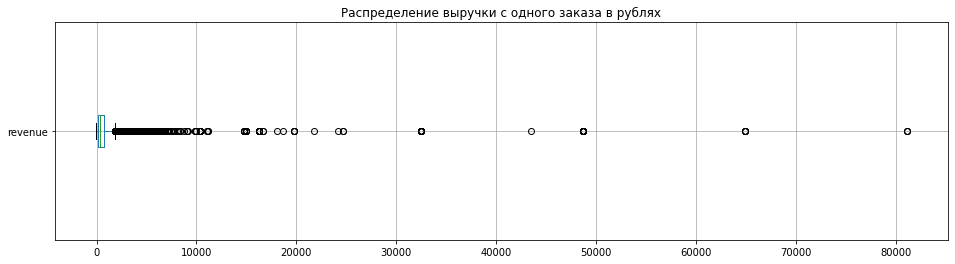

In [52]:
#построим диаграмму размаха
boxplot=rub_df.boxplot(column='revenue', vert=False, figsize=(16,4))
boxplot.set_title('Распределение выручки с одного заказа в рублях')
plt.show() 

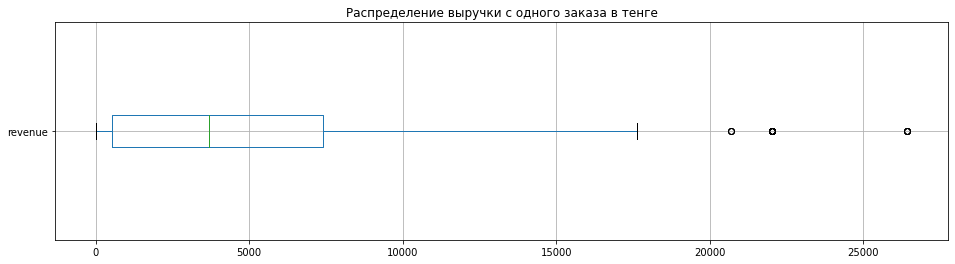

In [53]:
#построим диаграмму размаха
boxplot=kzt_df.boxplot(column='revenue', vert=False, figsize=(16,4))
boxplot.set_title('Распределение выручки с одного заказа в тенге')
plt.show() 

Распределение значения выручки с одного заказа несимметричное с положительной скошенностью как для данных в рублях, так и в тенге.

В распределениях присутствуют выбросы. Отберем значения по 99-ому процентилю и сделаем фильтрацию с условием, что значение выручки должно быть больше 0.

In [54]:
#рассчитаем 99-ый процентиль для заказов в рублях
rub_prc=rub_df['revenue'].quantile(0.99)
print(f'Значение 99-го процентиля для заказов в рублях равно {rub_prc}')

#рассчитаем 99-ый процентиль для заказов в тенге
kzt_prc=kzt_df['revenue'].quantile(0.99)
print(f'Для заказов в тенге - {kzt_prc}')

Значение 99-го процентиля для заказов в рублях равно 2570.8
Для заказов в тенге - 17617.24


In [55]:
#для удоства сделаем копию датафрейма
filtered_final_df=final_df.copy()

In [56]:
#избавимся от выбрасов
filtered_final_df=filtered_final_df[(filtered_final_df['revenue']>0)&
                                    (((filtered_final_df['currency_code']=='rub') & (filtered_final_df['revenue']<=rub_prc)) | 
                                    ((filtered_final_df['currency_code']=='kzt') & (filtered_final_df['revenue']<=kzt_prc)))]

rub_df=rub_df[(rub_df['revenue']>0)&(rub_df['revenue']<=rub_prc)]
kzt_df=kzt_df[(kzt_df['revenue']>0)&(kzt_df['revenue']<=kzt_prc)]

#выведем значение стандартного отклонения после избаления от выбрасов
rub_std=round(filtered_final_df[filtered_final_df['currency_code']=='rub']['revenue'].std(), 2)
print(f'Значение стандартного отклонения после избаления от выбрасов для заказов в рублях равно {rub_std}.')

kzt_std=round(filtered_final_df[filtered_final_df['currency_code']=='kzt']['revenue'].std(), 2)
print(f'Для заказов в тенге - {kzt_std}.')

Значение стандартного отклонения после избаления от выбрасов для заказов в рублях равно 500.6.
Для заказов в тенге - 4742.49.


Значение стандартного отклонения уменьшилось для данных в рублях с 871.75 до 500.6, для данных в тенге с 4916.75 до 4742.49.

Снова построим диаграммы размаха для того, чтобы оценить распределения.

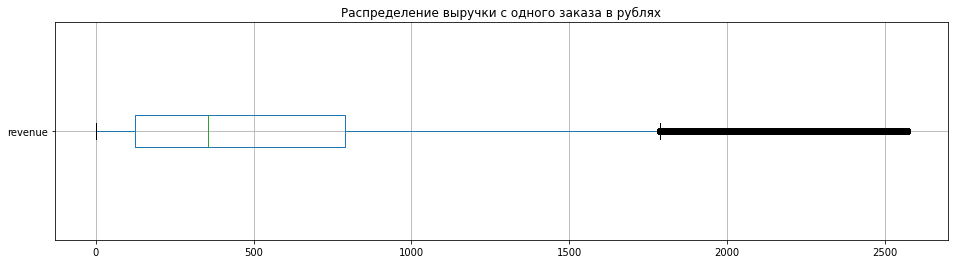

In [57]:
#построим диаграмму размаха
boxplot=rub_df.boxplot(column='revenue', vert=False, figsize=(16,4))
boxplot.set_title('Распределение выручки с одного заказа в рублях')
plt.show() 

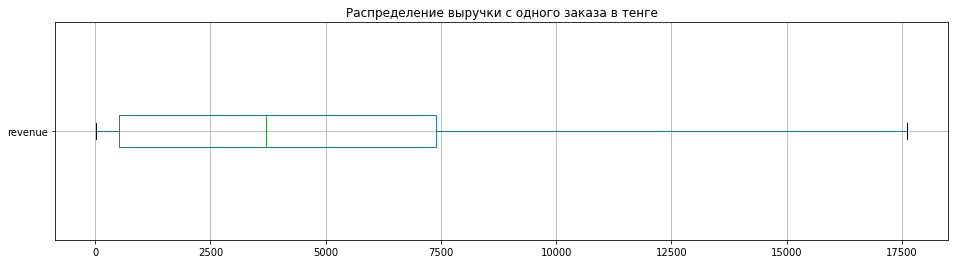

In [58]:
#построим диаграмму размаха
boxplot=kzt_df.boxplot(column='revenue', vert=False, figsize=(16,4))
boxplot.set_title('Распределение выручки с одного заказа в тенге')
plt.show() 

Проверим, сколько строк нам пришлось отбросить из-за удаления выбросов.

In [59]:
#вычисляем абсолютное и относительное количество удаленных строк
cnt_rows=final_df.shape[0]-filtered_final_df.shape[0]

#выводим результат
print(f'Количество строк сократилось с {final_df.shape[0]} до {filtered_final_df.shape[0]}. Было удалено {cnt_rows} строк.')

Количество строк сократилось с 290611 до 281875. Было удалено 8736 строк.


---
Проанализируем распределение столбца tickets_count.

In [60]:
#выведем основные статистические показатели столбца tickets_count
display(stat_param('tickets_count'))

Основные статистические показатели столбца tickets_count:


,index,rub,kzt
0,count,276841.00,5034.00
1,mean,2.74,2.75
2,std,1.16,1.10
3,min,1.00,1.00
4,25%,2.00,2.00
5,50%,3.00,3.00
6,75%,3.00,3.00
7,max,47.00,6.00


None

Согласно краткому статистическому описанию tickets_count

-для заказов в рублях:
* количество заказов составляет 285542;
* среднее количество билетов в заказе составляет 2.74 (так количество билетов это всегда целое число, стоит округлить значение до 2);
* минимальное количество билетов в заказе - 1 билет;
* максимальное - 47; 
* наиболее часто встречаются заказы, в которых преобретается 3 билета (медиана), что приближено к среднему;
* межквартильный размах равен 3-2=1;
* стандартное отклонение составляет 1.16.

-для заказов в тенге:
* количество заказов составляет 5069;
* среднее количество билетов в заказе составляет 2.75 (то есть 2);
* минимальное количество билетов в заказе - 1 билет;
* максимальное - 6; 
* наиболее часто встречаются заказы, в которых преобретается 3 билета (медиана), что приближено к среднему;
* межквартильный размах равен 3-2=1;
* стандартное отклонение составляет 1.1.

Построим диаграмму размаха для визуализации распределения.

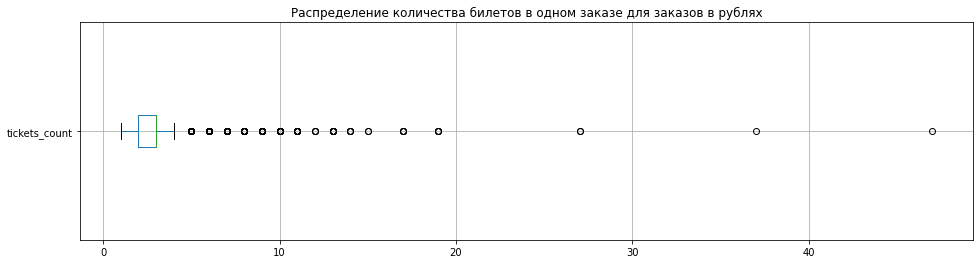

In [61]:
#построим диаграмму размаха
boxplot=rub_df.boxplot(column='tickets_count', vert=False, figsize=(16,4))
boxplot.set_title('Распределение количества билетов в одном заказе для заказов в рублях')
plt.show() 

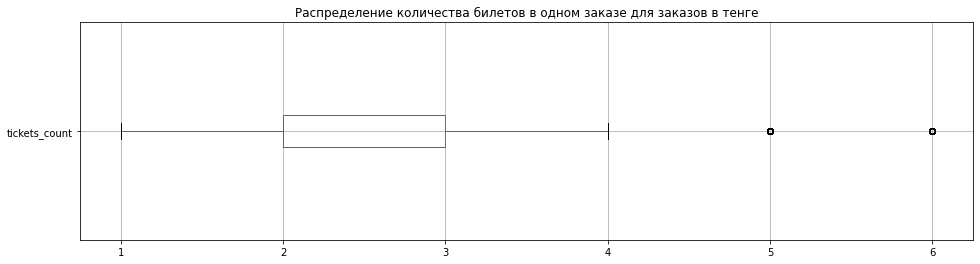

In [62]:
#построим диаграмму размаха
boxplot=kzt_df.boxplot(column='tickets_count', vert=False, figsize=(16,4))
boxplot.set_title('Распределение количества билетов в одном заказе для заказов в тенге')
plt.show() 

В распределении значений столбца tickets_count, описывающих заказы в рублях, присутствуют выбросы.

---
Проанализируем распределение столбца total.

In [63]:
#выведем основные статистические показатели столбца tickets_count
display(stat_param('total'))

Основные статистические показатели столбца total:


,index,rub,kzt
0,count,276841.00,5034.00
1,mean,6142.10,74078.29
2,std,5116.99,66170.93
3,min,0.93,288.88
4,25%,2243.15,9335.21
5,50%,4749.54,61647.16
6,75%,8744.74,114868.83
7,max,68049.59,287172.10


None

Согласно краткому статистическому описанию total

-для заказов в рублях:
* количество заказов составляет 285542;
* средний размер общей суммы заказа составляет 6131.16₽;
* минимальный размер общей суммы заказа составил 0.93₽, что является ошибкой, так сумма не может быть настолько маленькой, такое значение не реалистично;
* минимальный размер общей суммы заказа - 68049.59₽;
* наиболее часто встречаются заказы, общая сумма по которым составляет 4744.62₽ (медиана), что отличается от среднего;
* межквартильный размах равен 8741.18-2241.49=6499.69;
* стандартное отклонение составляет 5090.91.

-для заказов в тенге:
* количество заказов составляет 5069;
* средний размер общей суммы заказа составляет 74078.29₸;
* минимальный размер общей суммы заказа составил 288.88₸;
* максимальная - 287172.10₸;
* наиболее часто встречаются заказы, общая сумма по которым составляет 61647.16₸ (медиана), что отличается от среднего;
* межквартильный размах равен 114868.83-9335.21=105533.62;
* стандартное отклонение составляет 66170.93.

Построим диаграмму размаха для визуализации распределения.

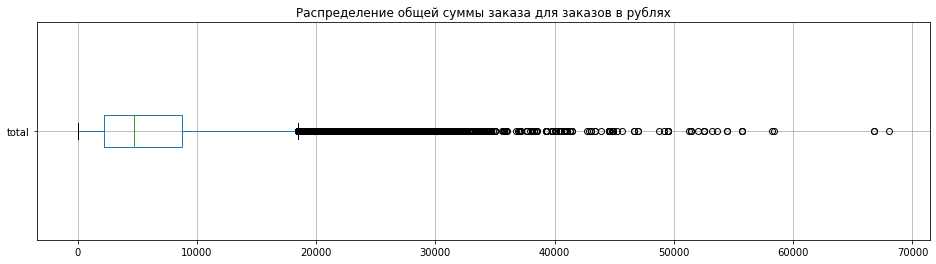

In [64]:
#построим диаграмму размаха
boxplot=rub_df.boxplot(column='total', vert=False, figsize=(16,4))
boxplot.set_title('Распределение общей суммы заказа для заказов в рублях')
plt.show() 

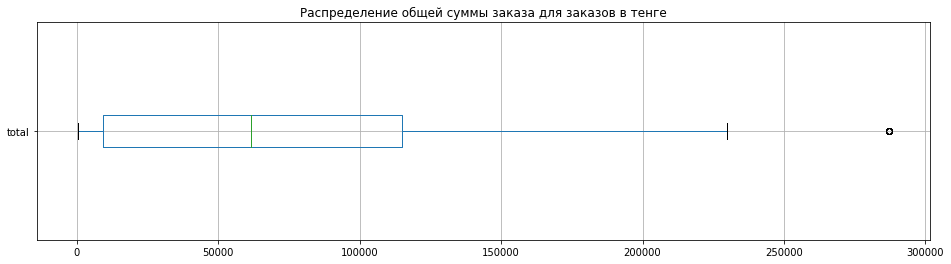

In [65]:
#построим диаграмму размаха
boxplot=kzt_df.boxplot(column='total', vert=False, figsize=(16,4))
boxplot.set_title('Распределение общей суммы заказа для заказов в тенге')
plt.show() 

Распределение значения общей суммы заказа несимметричное с положительной скошенностью как для данных в рублях, так и в тенге.

---
### 2.3. Наличие явных и неявных дубликатов
<a class="anchor" id="#23-bullet"></a>

---
Проверим наличие явных дубликатов.

In [66]:
#проверяем наличие явных дубликатов
print(filtered_final_df.duplicated().sum())

0


Все строки датафрейма уникальны, не содержат дубликатов.

---

Проверим наличие неявных дубликатов.

In [70]:
print(filtered_final_df[['user_id', 'created_dt_msk', 'created_ts_msk', 'event_id', 'cinema_circuit', 
                         'age_limit', 'currency_code', 'device_type_canonical', 'revenue', 'service_name',
                         'tickets_count', 'total', 'days_since_prev', 'event_name', 'event_type_description', 'event_type_main', 
                         'organizers', 'region_name', 'city_name', 'city_id', 'venue_id', 'venue_name', 'venue_address']].duplicated().sum())

29


Датафрейм содержит 29 неявных дубликатов. Удалим их.

In [74]:
#избавимся от дубликатов 
filtered_final_df=filtered_final_df.drop_duplicates(subset=['user_id', 'created_dt_msk', 'created_ts_msk', 'event_id', 'cinema_circuit', 
                         'age_limit', 'currency_code', 'device_type_canonical', 'revenue', 'service_name',
                         'tickets_count', 'total', 'days_since_prev', 'event_name', 'event_type_description', 'event_type_main', 
                         'organizers', 'region_name', 'city_name', 'city_id', 'venue_id', 'venue_name', 'venue_address'])

Проверим общее количество удаленных строк.

In [75]:
#вычисляем абсолютное и относительное количество удаленных строк
rows_cnt=final_df.shape[0]-filtered_final_df.shape[0]
rows_per=round(cnt_rows/final_df.shape[0]*100, 2)

#выводим результат
print(f'Количество строк сократилось с {final_df.shape[0]} до {filtered_final_df.shape[0]}. Было удалено {rows_cnt} строк, что составляет {rows_per}%.')

Количество строк сократилось с 290611 до 281846. Было удалено 8765 строк, что составляет 3.01%.


---
### 2.4. Типы данных
<a class="anchor" id="#24-bullet"></a>

Необходимо изменить типы для столбцов с данными о дате и времени created_dt_msk и created_ts_msk.

In [76]:
#меняем тип столбцов, приводя к datetime64
filtered_final_df['created_dt_msk']=pd.to_datetime(filtered_final_df['created_dt_msk'], errors='coerce', format='%Y-%m-%d')
filtered_final_df['created_ts_msk']=pd.to_datetime(filtered_final_df['created_ts_msk'], errors='coerce', format='%Y-%m-%d')

#проверим, что типы изменились
display(filtered_final_df.dtypes)

order_id                           int64
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int64
cinema_circuit                    object
age_limit                          int64
currency_code                     object
device_type_canonical             object
revenue                          float64
service_name                      object
tickets_count                      int64
total                            float64
days_since_prev                  float64
event_name                        object
event_type_description            object
event_type_main                   object
organizers                        object
region_name                       object
city_name                         object
city_id                            int64
venue_id                           int64
venue_name                        object
venue_address                     object
dtype: object

Типы столбцов created_dt_msk и created_ts_msk заменены.

### 2.5. Создание новых столбцов
<a class="anchor" id="#25-bullet"></a>

Для дальнейшей работы с данными необходимо создать несколько новых столбцов:
* revenue_rub — привести выручку с заказа к единой валюте — российскому рублю;
* one_ticket_revenue_rub — рассчитать выручку с продажи одного билета на мероприятие;
* month — выделить месяц оформления заказа в отдельный столбец;
* season — создать столбец с информацией о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

---
Выделим столбец revenue_rub. Для этого используем датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю final_tickets_tenge_df.csv за 2024 год. Значения в рублях представлены для 100 тенге.

In [77]:
#для удобства создадим копию датафрейма
new_cols_final_df=filtered_final_df.copy()

In [78]:
#меняем тип столбца, приводя к datetime64
final_tickets_tenge_df['data']=pd.to_datetime(final_tickets_tenge_df['data'], errors='coerce', format='%Y-%m-%d')

#объединим датафреймы
new_cols_final_df=pd.merge(filtered_final_df, final_tickets_tenge_df, left_on='created_dt_msk', right_on='data', how='left')

#функция вычисления значения нового столбца
def revenue_rub_col (row): 
    if row['currency_code']=='kzt':
        rubs=round(row['revenue']*row['curs']/100, 2)

    if row['currency_code']=='rub':
        rubs=row['revenue']
        
    return rubs

#создаем новый столбец
new_cols_final_df['revenue_rub']=new_cols_final_df.apply(revenue_rub_col, axis=1)

#удаляем ненужные
new_cols_final_df=new_cols_final_df.drop(['data', 'curs', 'nominal', 'cdx'], axis=1)

#проверим правильность работы функции
display(new_cols_final_df[new_cols_final_df['currency_code']=='rub'][['created_dt_msk', 'revenue', 'currency_code', 'revenue_rub']].head())
display(new_cols_final_df[new_cols_final_df['currency_code']=='kzt'][['created_dt_msk', 'revenue', 'currency_code', 'revenue_rub']].head())

,created_dt_msk,revenue,currency_code,revenue_rub
0,2024-08-20,1521.94,rub,1521.94
1,2024-07-23,1902.42,rub,1902.42
2,2024-07-23,1141.45,rub,1141.45
3,2024-07-23,1902.42,rub,1902.42
4,2024-07-23,1521.94,rub,1521.94


,created_dt_msk,revenue,currency_code,revenue_rub
8818,2024-09-17,518.10,kzt,98.50
8819,2024-09-20,518.10,kzt,100.27
8820,2024-09-24,388.57,kzt,75.37
8821,2024-09-24,647.62,kzt,125.62
8822,2024-09-24,388.57,kzt,75.37


---
Выделим столбец one_ticket_revenue_rub, в котором хранится информация о выручке с продажи одного билета.

In [79]:
#выделяем новый столбец
new_cols_final_df['one_ticket_revenue_rub']=round(new_cols_final_df['revenue_rub']/new_cols_final_df['tickets_count'], 2)

#проверяем его заполняемость
display(new_cols_final_df[['revenue_rub','tickets_count', 'one_ticket_revenue_rub']].head())

,revenue_rub,tickets_count,one_ticket_revenue_rub
0,1521.94,4,380.48
1,1902.42,5,380.48
2,1141.45,3,380.48
3,1902.42,5,380.48
4,1521.94,4,380.48


---
Выделим столбец month - месяц оформления заказа.

In [80]:
#выделяем новый столбец
new_cols_final_df['month']=new_cols_final_df['created_dt_msk'].dt.month

#проверяем его заполняемость
display(new_cols_final_df[['created_dt_msk','month']].head())

,created_dt_msk,month
0,2024-08-20,8
1,2024-07-23,7
2,2024-07-23,7
3,2024-07-23,7
4,2024-07-23,7


---
Выделим столбец season, который содержит информацию о времени года ('лето', 'осень', 'зима', 'весна').

In [81]:
#функция вычисления значения нового столбца
def season_col(row):
    if (row['month']<=2) or (row['month']==12):
        season='зима'

    elif 3<=row['month']<=5:
        season='весна'
    
    elif 6<=row['month']<=8:
        season='лето'
    
    else:
        season='осень'
        
    return season

#создаем новый столбец
new_cols_final_df['season']=new_cols_final_df.apply(season_col, axis=1)

#проверяем его заполняемость
display(new_cols_final_df[['month','season']].head())

,month,season
0,8,лето
1,7,лето
2,7,лето
3,7,лето
4,7,лето


---
Проверим характеристики готового датафрейма.

In [82]:
#сделаем его копию
ready_df=new_cols_final_df.copy()

display(ready_df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 281846 entries, 0 to 281845
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                281846 non-null  int64         
 1   user_id                 281846 non-null  object        
 2   created_dt_msk          281846 non-null  datetime64[ns]
 3   created_ts_msk          281846 non-null  datetime64[ns]
 4   event_id                281846 non-null  int64         
 5   cinema_circuit          281846 non-null  object        
 6   age_limit               281846 non-null  int64         
 7   currency_code           281846 non-null  object        
 8   device_type_canonical   281846 non-null  object        
 9   revenue                 281846 non-null  float64       
 10  service_name            281846 non-null  object        
 11  tickets_count           281846 non-null  int64         
 12  total                   281846

None

Таким образом, была выполнена загрузка и преобработка данных. 
<br>В ходе предобработки были изменены типы столбцов в соответствии с их содержанием, значения категориальных столбцов приведены к общему стилю, изучено распределение столбцов с числовыми значениями, было удалено 8736 строк. Пропусков и дубликатов, нуждающихся в обработке, выявлено не было. Были добавлены новые столбцы. 

Итоговый датафрейм содержит 28 столбцов и 281846 строк, размер датафрейма составляет 62.4+ MB.
<br>Данные готовы к анализу.

## 3. Исследовательский анализ данных
<a class="anchor" id="#3-bullet"></a>

### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения
<a class="anchor" id="#31-bullet"></a>

Проанализируем рост количества заказов за весь период.

In [83]:
#определим количество заказов по месяцам
act_by_months=ready_df.groupby('month')['order_id'].agg('nunique').reset_index()

#переименуем столбцы
act_by_months.columns=['month', 'orders_cnt']

display(act_by_months)

,month,orders_cnt
0,6,32899
1,7,37884
2,8,43168
3,9,68892
4,10,99003


In [84]:
#загружаем необходимую библиотеку
import seaborn as sns

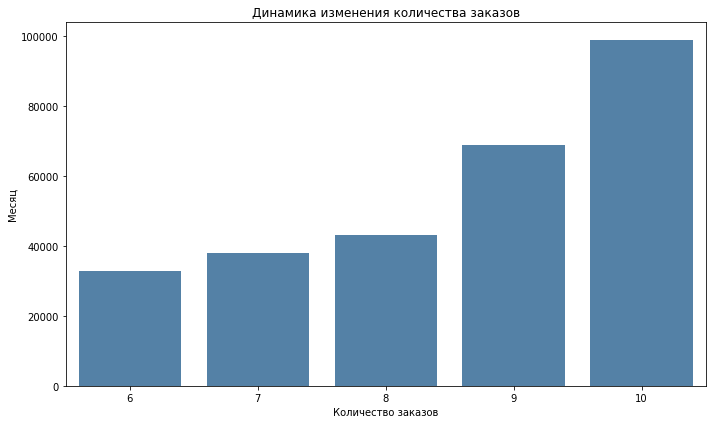

In [85]:
#построим столбчатую диаграмму
plt.figure(figsize=(10,6))
sns.barplot(data=act_by_months, orient='v', y='orders_cnt', x='month', color='steelblue')
plt.title('Динамика изменения количества заказов')
plt.ylabel('Месяц')
plt.xlabel('Количество заказов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show() 

Наблюдается сезонность, к осени количество заказов растет, поэтому проанализируем динамику пользовательской активности в разрезе:
* типа мероприятия event_type_main;
* типа устройства device_type_canonical;
* категорий мероприятий по возрастному рейтингу age_limit в связи с сезонностью.

---
#### 3.1.1 Динамика пользовательской активности в разрезе типа мероприятия.
<a class="anchor" id="#311-bullet"></a>

In [86]:
#определим количество заказов в разрезе типа мероприятия для каждого сезона
event_act_by_season=ready_df.groupby(['event_type_main','season'])['order_id'].agg('nunique').unstack()
event_act_by_season=event_act_by_season.sort_values(by='осень')

#определим изменение показателя в долях
event_difference_season=event_act_by_season.copy()
event_difference_season['difference']=round((event_difference_season['осень']-event_difference_season['лето'])/event_difference_season['лето'], 3)
event_difference_season=event_difference_season.sort_values(by='difference', ascending=True).reset_index()

display(event_difference_season)

season,event_type_main,лето,осень,difference
0,выставки,2407,2402,-0.002
1,стендап,6346,6923,0.091
2,другое,28479,32667,0.147
3,концерты,49986,62725,0.255
4,театр,23698,42709,0.802
5,ёлки,273,1691,5.194
6,спорт,2762,18778,5.799


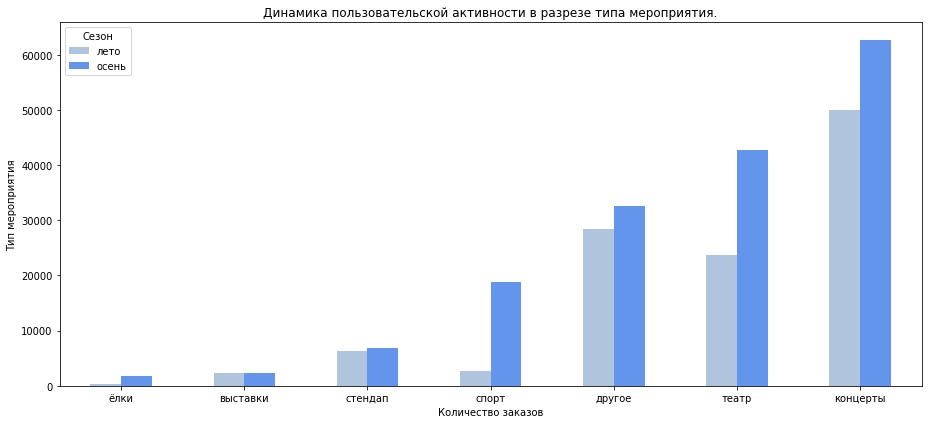

In [87]:
#строим столбчатую диаграмму динамики пользовательской активности
event_act_by_season.plot(kind='bar', figsize=(13,6), color=['lightsteelblue', 'cornflowerblue'])
plt.title('Динамика пользовательской активности в разрезе типа мероприятия.')
plt.ylabel('Тип мероприятия')
plt.xlabel('Количество заказов')
plt.legend(loc='best',title='Сезон')
plt.xticks(rotation=0)
plt.tight_layout()

Наибольшее количество заказов приходится на концерты, как летом (49986 заказов), так и осенью (62725 заказов). Менее популярными являются мероприятия, проходящие в театре (летом 23698 заказов, осенью - 42709.) Наименее популярными мероприятиями являются ёлки (273 заказов летом и 1691 осенью).

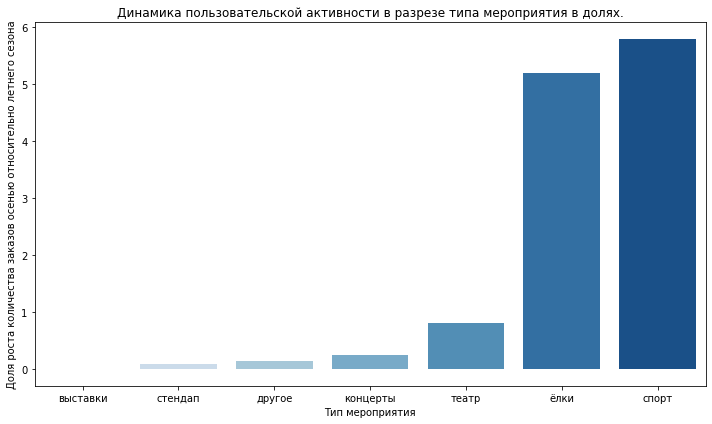

In [88]:
#строим столбчатую диаграмму динамики пользовательской активности в долях
plt.figure(figsize=(10,6))
sns.barplot(data=event_difference_season, orient='v', x='event_type_main', y='difference', palette='Blues')
plt.title('Динамика пользовательской активности в разрезе типа мероприятия в долях.')
plt.ylabel('Доля роста количества заказов осенью относительно летнего сезона')
plt.xlabel('Тип мероприятия')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show() 

По графику можно проследить, как изменялась пользовательская активность по сезонам, относительно определенного типа мероприятия. Наибольший относительный рост заказов отмечается для спортивных мероприятий (рост в 5.799 раз) и ёлок (рост в 5.194 раз), когда на выставки заказы билетов стали делать наоборот чуть реже (небольшой спад на 0.002).

Рассчитаем среднее значение выручки с одного билета для каждого мероприятия.

In [89]:
#определяем суммарное значение выручки со всех билетов и общее количество билетов, проданных на мероприятие по сезонам
avg_rev_event=ready_df.groupby(['event_type_main', 'season']).agg({'revenue_rub':'sum',
                                                                   'tickets_count':'sum'})
avg_rev_event['avg_revenue']=round(avg_rev_event['revenue_rub']/avg_rev_event['tickets_count'], 2)
avg_rev_event=avg_rev_event.drop(['revenue_rub', 'tickets_count'], axis=1).unstack()

#определим изменение показателя в долях
avg_rev_event_difference=avg_rev_event.reset_index().copy()
avg_rev_event_difference['difference']=round((avg_rev_event_difference['avg_revenue', 'осень']-avg_rev_event_difference['avg_revenue','лето'])/avg_rev_event_difference['avg_revenue','лето'], 3)
avg_rev_event_difference=avg_rev_event_difference.sort_values(by='difference', ascending=True)

display(avg_rev_event_difference)

event_type_main avg_revenue         difference
season                        лето   осень           
5                театр      213.44  176.47     -0.173
6                 ёлки      263.50  217.97     -0.173
2             концерты      307.67  269.72     -0.123
1               другое       92.63   83.33     -0.100
3                спорт       54.67   50.09     -0.084
0             выставки       89.53   93.46      0.044
4              стендап      215.22  228.67      0.062

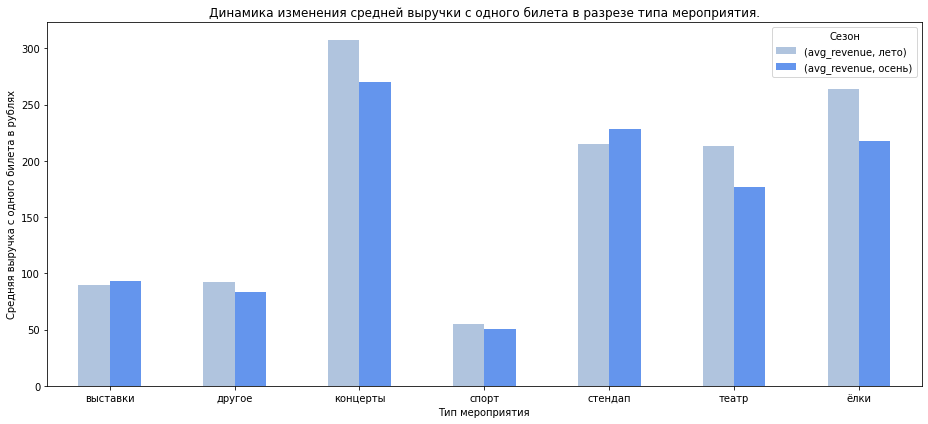

In [90]:
#строим столбчатую диаграмму динамики пользовательской активности
avg_rev_event.plot(kind='bar', figsize=(13,6), color=['lightsteelblue', 'cornflowerblue'])
plt.title('Динамика изменения средней выручки с одного билета в разрезе типа мероприятия.')
plt.xlabel('Тип мероприятия')
plt.ylabel('Средняя выручка с одного билета в рублях')
plt.legend(loc='best',title='Сезон')
plt.xticks(rotation=0)
plt.tight_layout()

Наибольшая средняя выручка с одного билета приходится на концерты, как летом (307.67₽), так и осенью (269.72₽). На втором месте по средней выручке за лето ёлки (263.50₽), за осень - стендап (228.67₽). Меньше всего выручки с одного билета сервис получает от спортивных мероприятий (летом 54.67₽, осенью 50.09₽).

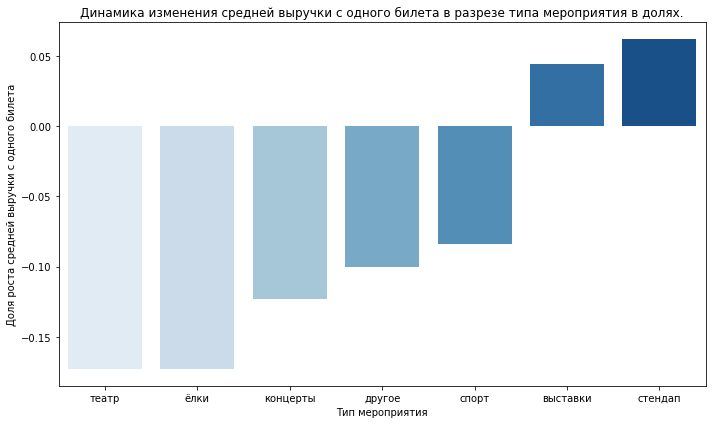

In [91]:
#строим столбчатую диаграмму изменения средней выручки с одного билета в долях
plt.figure(figsize=(10,6))
sns.barplot(data=avg_rev_event_difference, orient='v', x='event_type_main', y='difference', palette='Blues')
plt.title('Динамика изменения средней выручки с одного билета в разрезе типа мероприятия в долях.')
plt.ylabel('Доля роста средней выручки с одного билета')
plt.xlabel('Тип мероприятия')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show() 

По графику видно, что для большей части типов мероприятий среднее значение выручки с одного билета уменьшилось осенью. 
<br>Средняя выручка с одного билета в театр и на ёлки уменьшилась на 0.173. Рост показателя наблюдается для выставок (0.044) и стендапа (0.062).

---
#### 3.1.2 Динамика пользовательской активности в разрезе типа устройства.
<a class="anchor" id="#312-bullet"></a>

In [92]:
#определим количество заказов в разрезе типа устройства для каждого сезона
device_act_by_season=ready_df.groupby(['device_type_canonical','season'])['order_id'].agg('nunique').unstack()
device_act_by_season=device_act_by_season.sort_values(by='осень')

#определим изменение показателя в долях
device_difference_season=device_act_by_season.copy()
device_difference_season['difference']=round((device_difference_season['осень']-device_difference_season['лето'])/device_difference_season['лето'], 3)
device_difference_season=device_difference_season.sort_values(by='difference', ascending=True).reset_index()

display(device_difference_season)

season,device_type_canonical,лето,осень,difference
0,mobile,92171,133656,0.450
1,desktop,21780,34239,0.572


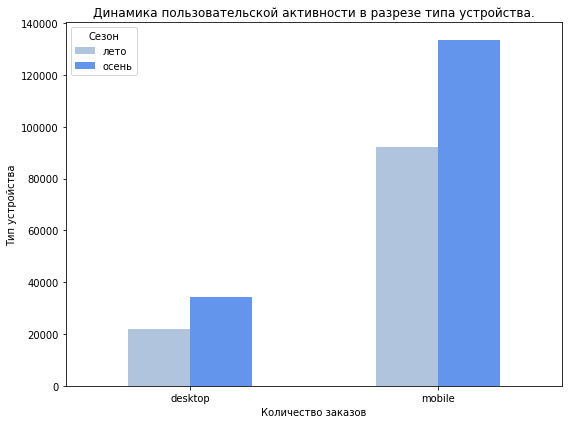

In [93]:
#строим столбчатую диаграмму динамики пользовательской активности
device_act_by_season.plot(kind='bar', figsize=(8,6), color=['lightsteelblue', 'cornflowerblue'])
plt.title('Динамика пользовательской активности в разрезе типа устройства.')
plt.ylabel('Тип устройства')
plt.xlabel('Количество заказов')
plt.legend(loc='best',title='Сезон')
plt.xticks(rotation=0)
plt.tight_layout()

Большее количество заказов и летом иосенью приходится на мобильные устройства (летом 92171 заказов, осенью - 133656). С ПК заказов поступает примерно в четыре раза меньше (21780 заказов в летний сезон, осенью 34239 заказов).

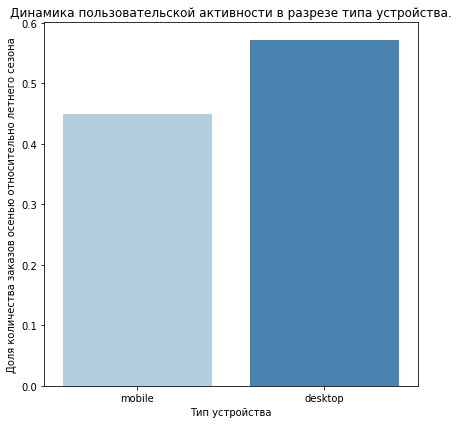

In [94]:
#строим столбчатую диаграмму динамики пользовательской активности в долях
plt.figure(figsize=(6,6))
sns.barplot(data=device_difference_season, orient='v', x='device_type_canonical', y='difference', palette='Blues')
plt.title('Динамика пользовательской активности в разрезе типа устройства.')
plt.ylabel('Доля количества заказов осенью относительно летнего сезона')
plt.xlabel('Тип устройства')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show() 

Количество заказов с мобильного устройства осенью выросло на 0.450, с ПК рост был сильнее, на 0.572 больше заказов, чем летом.

Рассчитаем среднее значение выручки с одного билета для каждого типа устройства.

In [95]:
#определяем суммарное значение выручки со всех билетов и общее количество билетов, 
#проданных с определенного типа устройства по сезонам
avg_rev_device=ready_df.groupby(['device_type_canonical', 'season']).agg({'revenue_rub':'sum',
                                                                          'tickets_count':'sum'})
avg_rev_device['avg_revenue']=round(avg_rev_device['revenue_rub']/avg_rev_device['tickets_count'], 2)
avg_rev_device=avg_rev_device.drop(['revenue_rub', 'tickets_count'], axis=1).unstack()

#определим изменение показателя в долях
avg_rev_device_difference=avg_rev_device.reset_index().copy()
avg_rev_device_difference['difference']=round((avg_rev_device_difference['avg_revenue', 'осень']-avg_rev_device_difference['avg_revenue','лето'])/avg_rev_device_difference['avg_revenue','лето'], 3)
avg_rev_device_difference=avg_rev_device_difference.sort_values(by='difference', ascending=True)

display(avg_rev_device_difference)

device_type_canonical avg_revenue         difference
season                              лето   осень           
0                    desktop      233.61  169.25     -0.276
1                     mobile      211.75  179.71     -0.151

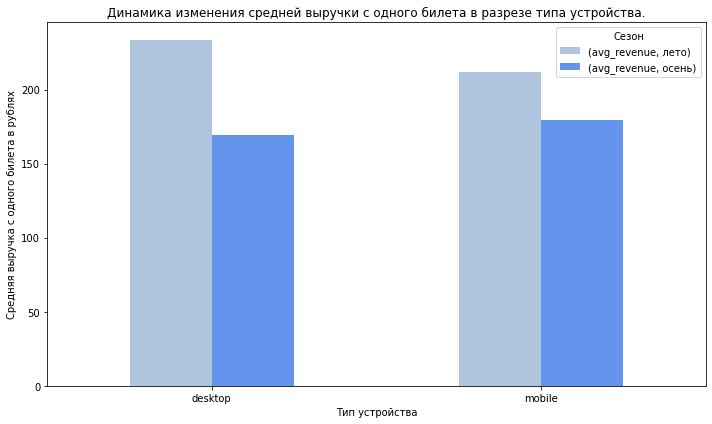

In [96]:
#строим столбчатую диаграмму динамики пользовательской активности
avg_rev_device.plot(kind='bar', figsize=(10,6), color=['lightsteelblue', 'cornflowerblue'])
plt.title('Динамика изменения средней выручки с одного билета в разрезе типа устройства.')
plt.xlabel('Тип устройства')
plt.ylabel('Средняя выручка с одного билета в рублях')
plt.legend(loc='best',title='Сезон')
plt.xticks(rotation=0)
plt.tight_layout()

Для ПК средняя выручка с билета за лето составила 233.61₽, за осень - 169.25₽, для мобильного устройства за лето - 211.75₽, за осень - 179.71₽.

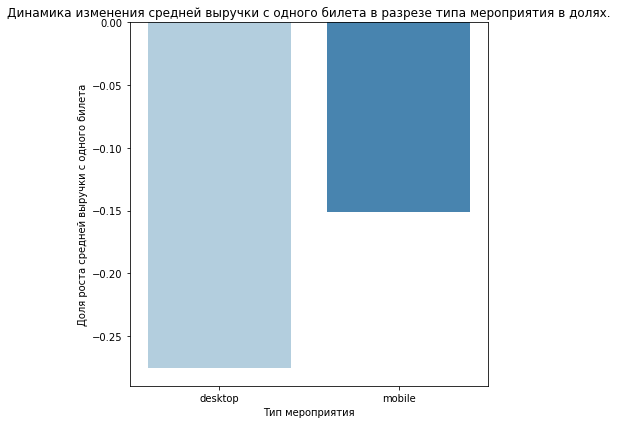

In [97]:
#строим столбчатую диаграмму изменения средней выручки с одного билета в долях
plt.figure(figsize=(6,6))
sns.barplot(data=avg_rev_device_difference, orient='v', x='device_type_canonical', y='difference', palette='Blues')
plt.title('Динамика изменения средней выручки с одного билета в разрезе типа мероприятия в долях.')
plt.ylabel('Доля роста средней выручки с одного билета')
plt.xlabel('Тип мероприятия')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show() 

И для заказов с ПК (-0.276), и для мобильных устройств (-0.151) средняя выручка с одного билета упала.

---
#### 3.1.3 Динамика пользовательской активности по возрастному рейтингу.
<a class="anchor" id="#313-bullet"></a>

In [98]:
#определим количество заказов по возрастному рейтингу для каждого сезона
age_act_by_season=ready_df.groupby(['age_limit','season'])['order_id'].agg('nunique').unstack()
age_act_by_season=age_act_by_season.sort_values(by='осень')

#определим изменение показателя в долях
age_difference_season=age_act_by_season.copy()
age_difference_season['difference']=round((age_difference_season['осень']-age_difference_season['лето'])/age_difference_season['лето'], 3)
age_difference_season=age_difference_season.sort_values(by='difference', ascending=True).reset_index()

display(age_difference_season)

season,age_limit,лето,осень,difference
0,18,15815,17539,0.109
1,16,32390,44205,0.365
2,6,20880,29640,0.420
3,12,24205,37226,0.538
4,0,20661,39285,0.901


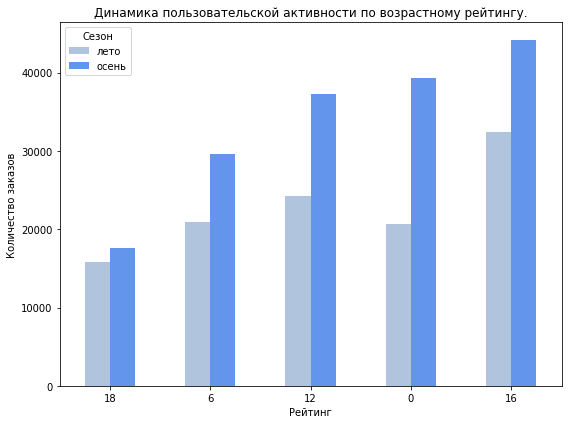

In [99]:
#строим столбчатую диаграмму динамики пользовательской активности
age_act_by_season.plot(kind='bar', figsize=(8,6), color=['lightsteelblue', 'cornflowerblue'])
plt.title('Динамика пользовательской активности по возрастному рейтингу.')
plt.xlabel('Рейтинг')
plt.ylabel('Количество заказов')
plt.legend(loc='best',title='Сезон')
plt.xticks(rotation=0)
plt.tight_layout()

Наиболее популярными по количеству заказов летом и осенью являются мероприятия 16+ (32390 заказов летом, 44205 осенью), на втором месте по заказам осенью оказались мероприятия 0+ (39285 заказов), когда летом это место занимали меропрития с рейтингом 12+ (24205 заказов). Наименее популяными и летом и осенью являются мероприятия 18+ (15815 заказов летом и 17539 осенью), что объясняется более узкой аудиторией.

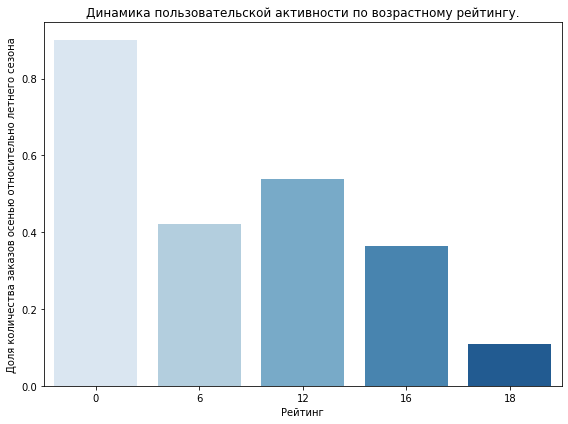

In [100]:
#строим столбчатую диаграмму динамики пользовательской активности в долях
plt.figure(figsize=(8,6))
sns.barplot(data=age_difference_season, orient='v', x='age_limit', y='difference', palette='Blues')
plt.title('Динамика пользовательской активности по возрастному рейтингу.')
plt.ylabel('Доля количества заказов осенью относительно летнего сезона')
plt.xlabel('Рейтинг')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show() 

Наибольший относительный рост заказов отмечается для мероприятий с рейтингом 0+ (рост на 0.901) и 12+ (рост на 0.538), наименьший рост наблюдается для мероприятий 18+ (0.109).

Рассчитаем среднее значение выручки с одного билета для каждого возрастного рейтинга.

In [101]:
#определяем суммарное значение выручки со всех билетов и общее количество билетов, 
#проданных на мероприятия с определенным рейтингом по сезонам
avg_rev_age=ready_df.groupby(['age_limit', 'season']).agg({'revenue_rub':'sum',
                                                           'tickets_count':'sum'})
avg_rev_age['avg_revenue']=round(avg_rev_age['revenue_rub']/avg_rev_age['tickets_count'], 2)
avg_rev_age=avg_rev_age.drop(['revenue_rub', 'tickets_count'], axis=1).unstack()

#определим изменение показателя в долях
avg_rev_age_difference=avg_rev_age.reset_index().copy()
avg_rev_age_difference['difference']=round((avg_rev_age_difference['avg_revenue', 'осень']-avg_rev_age_difference['avg_revenue','лето'])/avg_rev_age_difference['avg_revenue','лето'], 3)
avg_rev_age_difference=avg_rev_age_difference.sort_values(by='difference', ascending=True)

display(avg_rev_age_difference)

age_limit avg_revenue         difference
season                  лето   осень           
2             12      284.27  215.19     -0.243
0              0       98.05   77.78     -0.207
1              6      215.34  180.71     -0.161
3             16      247.76  228.99     -0.076
4             18      219.35  215.80     -0.016

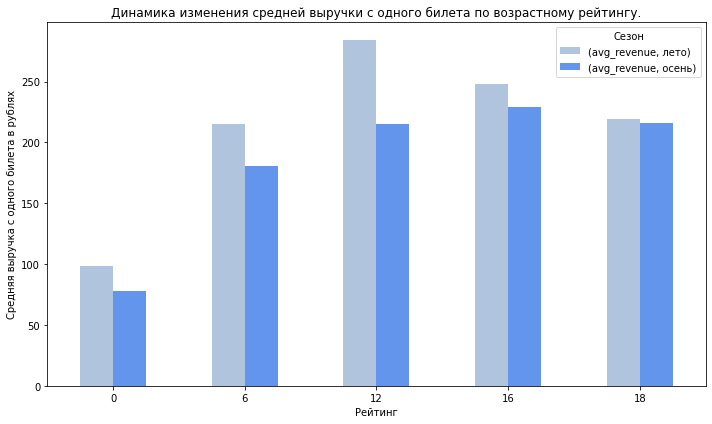

In [102]:
#строим столбчатую диаграмму динамики пользовательской активности
avg_rev_age.plot(kind='bar', figsize=(10,6), color=['lightsteelblue', 'cornflowerblue'])
plt.title('Динамика изменения средней выручки с одного билета по возрастному рейтингу.')
plt.xlabel('Рейтинг')
plt.ylabel('Средняя выручка с одного билета в рублях')
plt.legend(loc='best',title='Сезон')
plt.xticks(rotation=0)
plt.tight_layout()

Наибольшая средняя выручка с одного билета за лето наблюдается у мероприятий срейтингом 12+ (284.27₽), за осень - у мероприятий с рейтингом 16+ (228.99₽), наименьшую выручку с одного билета имеют мероприятия с рейтингом 0+ (98.05₽ летом и	77.78₽ осенью).

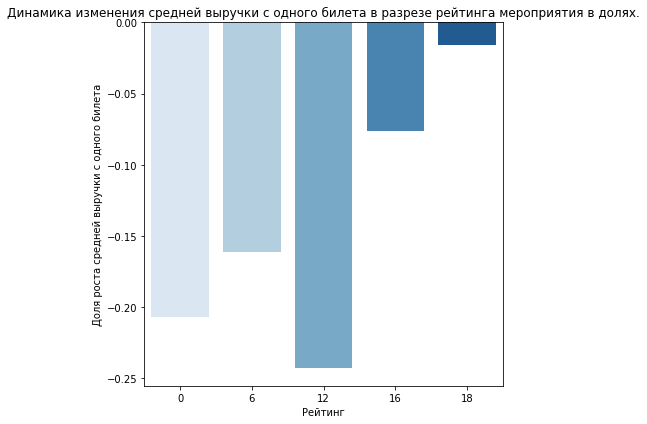

In [103]:
#строим столбчатую диаграмму изменения средней выручки с одного билета в долях
plt.figure(figsize=(6,6))
sns.barplot(data=avg_rev_age_difference, orient='v', x='age_limit', y='difference', palette='Blues')
plt.title('Динамика изменения средней выручки с одного билета в разрезе рейтинга мероприятия в долях.')
plt.ylabel('Доля роста средней выручки с одного билета')
plt.xlabel('Рейтинг')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show() 

Изменение средней выручки с одного билета по рейтингу мероприятий для всех типов отрицательное. Больше всего в относительном плане уменьшилась средняя выручка для мероприятий с рейтингом 12+ (-0.243), меньше всего изменилась средняя выручка для мероприятий с рейтингом 18+ (-0.016).

---
Для разных категорий сегментов осенью наблюдается рост числа заказов, но выручка с одного билета падает, относительно летнего сезона. Это может быть связано с изменением условий взамодействия с партнерами сервиса.

---
### 3.2. Осенняя активность пользователей
<a class="anchor" id="#32-bullet"></a>
Проанализируем динамику изменений по дням для:
* общего числа заказов;
* количества активных пользователей DAU;
* среднего числа заказов на одного пользователя;
* средней стоимости одного билета.

Изучим недельную цикличность. Выделим день недели, чтобы сравнить пользовательскую активность в будни и выходные.

Так как необходимо рассчитать среднюю стоимость одного билета, переведем все значения столбца total в рубли. Также выделим столбец с днем недели.

In [104]:
#создадим копию
ready_df_rub=ready_df.copy()

#объединим датафреймы
ready_df_rub=pd.merge(ready_df_rub, final_tickets_tenge_df, left_on='created_dt_msk', right_on='data', how='left')

#функция вычисления значения нового столбца
def total_rub_col (row): 
    if row['currency_code']=='kzt':
        rubs=round(row['total']*row['curs']/100, 2)

    if row['currency_code']=='rub':
        rubs=row['total']
        
    return rubs

#создаем новые столбцы
ready_df_rub['total_rub']=ready_df_rub.apply(total_rub_col, axis=1)
ready_df_rub['day_of_week']=ready_df_rub['created_dt_msk'].dt.dayofweek

#удаляем ненужные
ready_df_rub=ready_df_rub.drop(['data', 'curs', 'nominal', 'cdx'], axis=1)

#проверим правильность работы функции
display(ready_df_rub[ready_df_rub['currency_code']=='rub'][['created_dt_msk', 'day_of_week', 'total', 'currency_code', 'total_rub']].head())
display(ready_df_rub[ready_df_rub['currency_code']=='kzt'][['created_dt_msk', 'day_of_week', 'total', 'currency_code', 'total_rub']].head())

,created_dt_msk,day_of_week,total,currency_code,total_rub
0,2024-08-20,1,10870.99,rub,10870.99
1,2024-07-23,1,13588.74,rub,13588.74
2,2024-07-23,1,8153.25,rub,8153.25
3,2024-07-23,1,13588.74,rub,13588.74
4,2024-07-23,1,10870.99,rub,10870.99


,created_dt_msk,day_of_week,total,currency_code,total_rub
8818,2024-09-17,1,10361.97,kzt,1970.07
8819,2024-09-20,4,10361.97,kzt,2005.41
8820,2024-09-24,1,7771.48,kzt,1507.41
8821,2024-09-24,1,12952.47,kzt,2512.35
8822,2024-09-24,1,7771.48,kzt,1507.41


Составим таблицу с динамикой изменения метрик по дням.

In [105]:
#создадим новый датафрейм
metric_by_day=ready_df_rub[ready_df_rub['season']=='осень'].groupby(['created_dt_msk', 'day_of_week']).agg({'order_id':'nunique',
                                                                                                            'user_id':'nunique',
                                                                                                            'tickets_count':'sum',
                                                                                                            'total_rub':'sum'}).reset_index()
#переименуем столбцы для удобства
metric_by_day.columns=['date', 'day_of_week', 'orders_cnt', 'DAU', 'tickets_cnt', 'total_sum']

#добавим оставшиеся столбцы
metric_by_day['avg_orders_cnt_by_user']=round(metric_by_day['orders_cnt']/metric_by_day['DAU'], 2)
metric_by_day['tickets_avg_cost']=round(metric_by_day['total_sum']/metric_by_day['tickets_cnt'], 2)

#удаляем ненужные столбцы
metric_by_day=metric_by_day.drop(['tickets_cnt', 'total_sum'], axis=1)
metric_by_day=metric_by_day.sort_values(by='date')

display(metric_by_day.head(10))

,date,day_of_week,orders_cnt,DAU,avg_orders_cnt_by_user,tickets_avg_cost
0,2024-09-01,6,1314,555,2.37,2278.22
1,2024-09-02,0,1370,571,2.40,2219.03
2,2024-09-03,1,5090,776,6.56,1264.59
3,2024-09-04,2,1758,684,2.57,2183.57
4,2024-09-05,3,1940,738,2.63,2215.29
5,2024-09-06,4,2065,835,2.47,2110.18
6,2024-09-07,5,1856,734,2.53,2290.34
7,2024-09-08,6,1598,656,2.44,2247.98
8,2024-09-09,0,2086,776,2.69,1898.18
9,2024-09-10,1,2009,762,2.64,2157.75


---
#### 3.2.1 Динамика общего числа заказов по дням
<a class="anchor" id="#321-bullet"></a>

In [106]:
#для удобства настроим количество подписей для оси ОХ
ticks=[]
ticks.append(metric_by_day['date'][0])

#отобразим только нечетные числа
for item_index in metric_by_day['date'].index:
    if item_index%2==0:
        ticks.append(metric_by_day['date'][item_index])

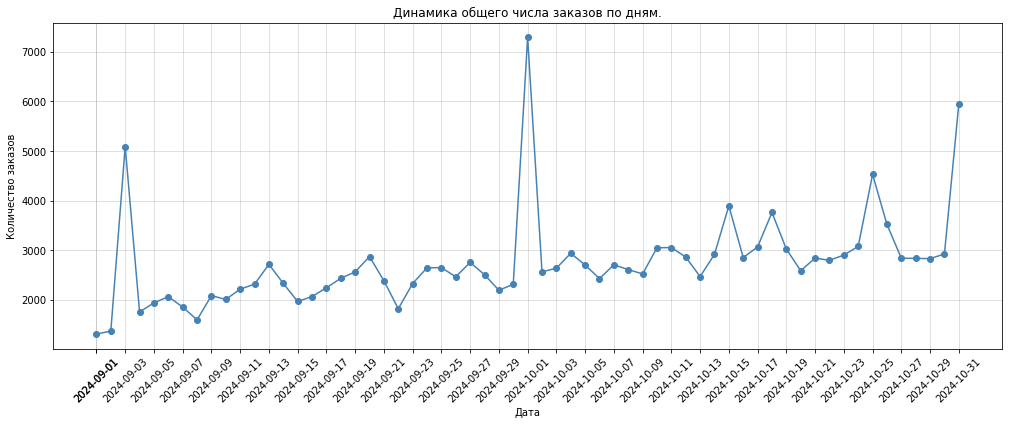

Значения меняются в диапазоне от 1314 до 7288.


In [107]:
#строим линейный график
plt.figure(figsize=(17, 6))
plt.plot(metric_by_day['date'], metric_by_day['orders_cnt'], marker='o', color='steelblue')
plt.title('Динамика общего числа заказов по дням.')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.xticks(ticks, rotation=45)
plt.grid(alpha=0.5)

plt.show()

#определяем диапазон изменения показателя
orders_min=min(metric_by_day['orders_cnt'])
orders_max=max(metric_by_day['orders_cnt'])
print(f'Значения меняются в диапазоне от {orders_min} до {orders_max}.')

Наблюдается тенденция к росту количества заказов, хотя и рост носит непостоянный характер, так как наблюдаются как пики, так и снижения показателя. Наблюдаем особенно высокие значения 03-09, 01-10, 15-10, 18-10, 25-10 и 31-10. Провалы наблюдаются 08-09, 15-09, 22-09.

---
#### 3.2.2 Динамика количества активных пользователей DAU
<a class="anchor" id="#322-bullet"></a>

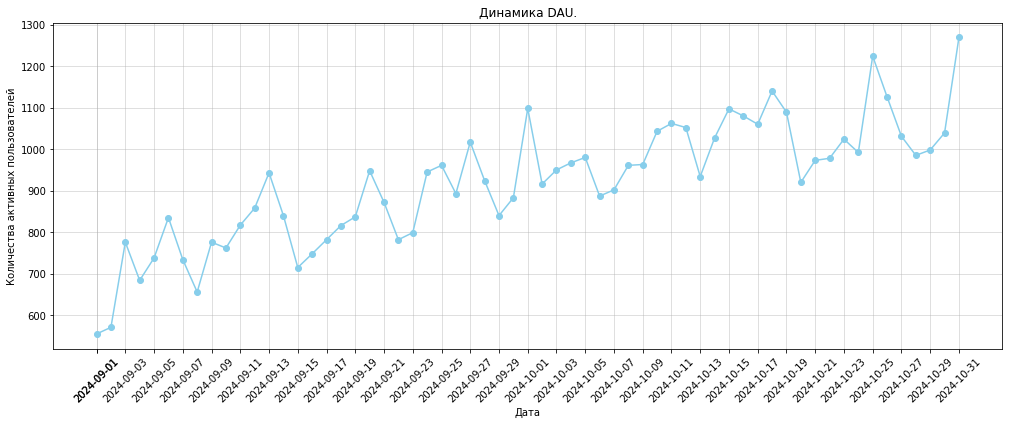

Значения меняются в диапазоне от 555 до 1269.


In [108]:
#строим линейный график
plt.figure(figsize=(17, 6))
plt.plot(metric_by_day['date'], metric_by_day['DAU'], marker='o', color='skyblue')
plt.title('Динамика DAU.')
plt.xlabel('Дата')
plt.ylabel('Количества активных пользователей')
plt.xticks(ticks, rotation=45)
plt.grid(alpha=0.5)

plt.show()

#определяем диапазон изменения показателя
DAU_min=min(metric_by_day['DAU'])
DAU_max=max(metric_by_day['DAU'])
print(f'Значения меняются в диапазоне от {DAU_min} до {DAU_max}.')

Наблюдается тенденция к росту количества активных пользователей, рост носит непостоянный характер, наблюдаются пики и провалы.

Проанализируем изменение показателя по дням недели.

In [109]:
#сгруппируем значения по дню недели
DAU_day_of_week=metric_by_day.groupby('day_of_week')['DAU'].agg('sum').reset_index()

display(DAU_day_of_week)

,day_of_week,DAU
0,0,7664
1,1,8397
2,2,8300
3,3,8640
4,4,8136
5,5,7617
6,6,7320


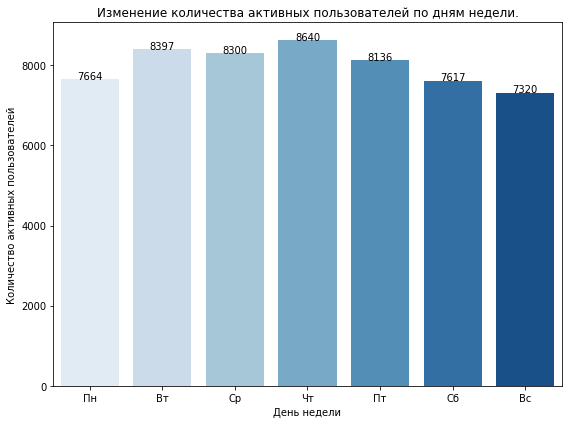

In [110]:
#строим столбчатую диаграмму изменения показателя по дням недели
plt.figure(figsize=(8,6))
sns.barplot(data=DAU_day_of_week, orient='v', x='day_of_week', y='DAU', palette='Blues')
plt.title('Изменение количества активных пользователей по дням недели.')
plt.ylabel('Количество активных пользователей')
plt.xlabel('День недели')
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
plt.tight_layout()

#добавляем подписи для наглядности
for index, value in enumerate(DAU_day_of_week['DAU']):
    plt.text(index, value, str(value), ha='center')

plt.show() 

Наибольшее количество активных пользователей наблюдается по четвергам, вторникам и средам, то есть в середине недели, после чего к выходным значение показателя снижается. Наименьшее количество активных пользователей наблюдается в воскресенье.

---
#### 3.2.3 Динамика среднего числа заказов на одного пользователя по дням
<a class="anchor" id="#323-bullet"></a>

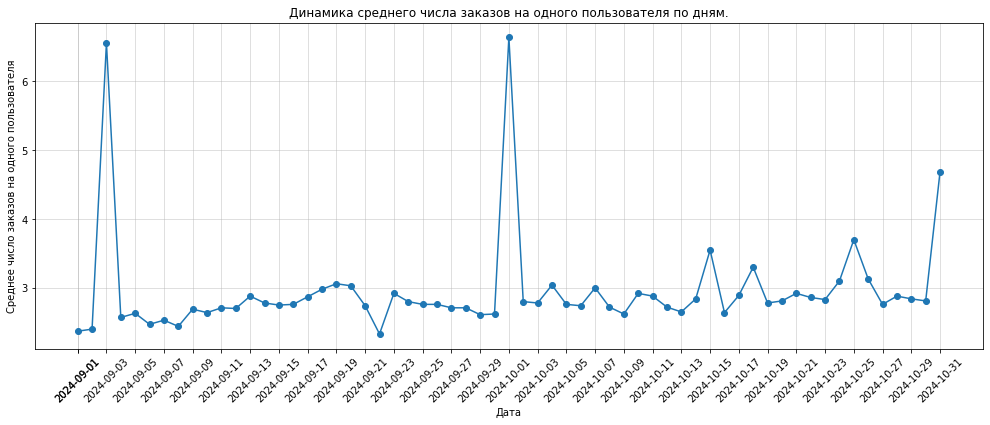

Значения меняются в диапазоне от 2.33 до 6.64.


In [111]:
#строим линейный график
plt.figure(figsize=(17, 6))
plt.plot(metric_by_day['date'], metric_by_day['avg_orders_cnt_by_user'], marker='o')
plt.title('Динамика среднего числа заказов на одного пользователя по дням.')
plt.xlabel('Дата')
plt.ylabel('Среднее число заказов на одного пользователя')
plt.xticks(ticks, rotation=45)
plt.grid(alpha=0.5)

plt.show()

#определяем диапазон изменения показателя
avg_order_min=min(metric_by_day['avg_orders_cnt_by_user'])
avg_order_max=max(metric_by_day['avg_orders_cnt_by_user'])
print(f'Значения меняются в диапазоне от {avg_order_min} до {avg_order_max}.')

Наблюдается небольшой непостоянный рост. 03-09 и 01-10 резкие скачки показателя вверх. Возможно, в эти дни проходили акции на покупку билетов. Также высокие значения наблюдались 15-10, 18-10, 25-10 и 31-10. Сильный провал приходится на 22-09.

---
#### 3.2.4 Динамика средней стоимости одного билета по дням
<a class="anchor" id="#324-bullet"></a>

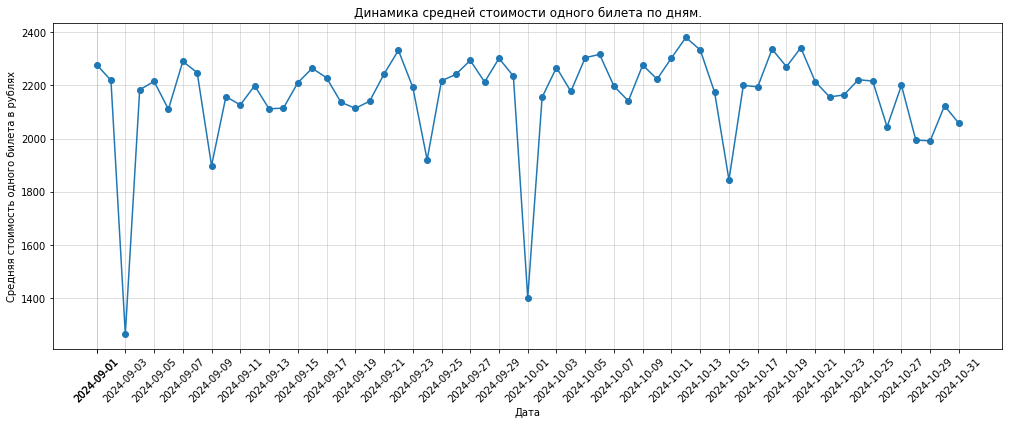

Значения меняются в диапазоне от 1264.59 до 2380.53.


In [112]:
#строим линейный график
plt.figure(figsize=(17, 6))
plt.plot(metric_by_day['date'], metric_by_day['tickets_avg_cost'], marker='o')
plt.title('Динамика средней стоимости одного билета по дням.')
plt.xlabel('Дата')
plt.ylabel('Средняя стоимость одного билета в рублях')
plt.xticks(ticks, rotation=45)
plt.grid(alpha=0.5)

plt.show()

#определяем диапазон изменения показателя
tickets_avg_min=min(metric_by_day['tickets_avg_cost'])
tickets_avg_max=max(metric_by_day['tickets_avg_cost'])
print(f'Значения меняются в диапазоне от {tickets_avg_min} до {tickets_avg_max}.')

Значение средней стоимости билета изменяется непостоянно. Особенно низкие значения наблюдались 03-09 и 01-10, также провалы в значениях отмечаются 09-09, 24-09 и 15-10. Возможно, в эти дни проводились акции. С 20-10 наблюдается уменьшение средней стоимости одного билета.

### 3.3. Популярные события и партнёры
<a class="anchor" id="#33-bullet"></a>

Рассмотрим, как события распределены по регионам и партнёрам. Это позволит выделить ключевые регионы и партнёров, которые вносят наибольший вклад в выручку.
* Для каждого региона посчитаем уникальное количество мероприятий и общее число заказов. Выделим, в каких регионах предлагается наибольшее разнообразие мероприятий.
* Для каждого билетного партнёра посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов. Выделим наиболее активных партнёрах.

При исследовании опираться будем не только на абсолютные значения, но и на доли.

---
#### 3.3.1 Исследование регионов
<a class="anchor" id="#331-bullet"></a>

Создадим таблицу для исследований.

In [113]:
#делаем группировку по регионам за осень
regions_df=ready_df[ready_df['season']=='осень'].groupby('region_name').agg({'event_name':'nunique',
                                                                             'order_id':'nunique'}).reset_index()
#для удоства меняем названия колонок
regions_df.columns=['region_name', 'events_cnt', 'orders_cnt']

#вычисляем константы для получения значений в долях
events_total_cnt=ready_df[ready_df['season']=='осень']['event_name'].nunique()
orders_total_cnt=ready_df[ready_df['season']=='осень']['order_id'].nunique()

#создаем столбцы с данными в долях
regions_df['events_part']=round(regions_df['events_cnt']/events_total_cnt, 2)
regions_df['orders_part']=round(regions_df['orders_cnt']/orders_total_cnt, 2)

---
Выделим топ-10 регионов по количеству уникальных мероприятий.

In [114]:
#выделяем топ-10 по относительному количеству мероприятий
regions_df=regions_df.sort_values(by='events_part', ascending=False)
top_10_regions_events=regions_df.head(10)
display(top_10_regions_events)

,region_name,events_cnt,orders_cnt,events_part,orders_part
23,каменевский_регион,3270,46576,0.30,0.28
59,североярская_область,2238,20626,0.20,0.12
56,светополянский_округ,704,4752,0.06,0.03
75,широковская_область,666,8645,0.06,0.05
51,речиновская_область,494,3565,0.05,0.02
60,серебринская_область,401,4467,0.04,0.03
64,солнечнореченская_область,280,2880,0.03,0.02
11,горицветская_область,349,3230,0.03,0.02
67,тепляковская_область,376,2485,0.03,0.01
22,зоринский_регион,279,1993,0.03,0.01


Визуализируем результат в виде линейчатой диагаммы.

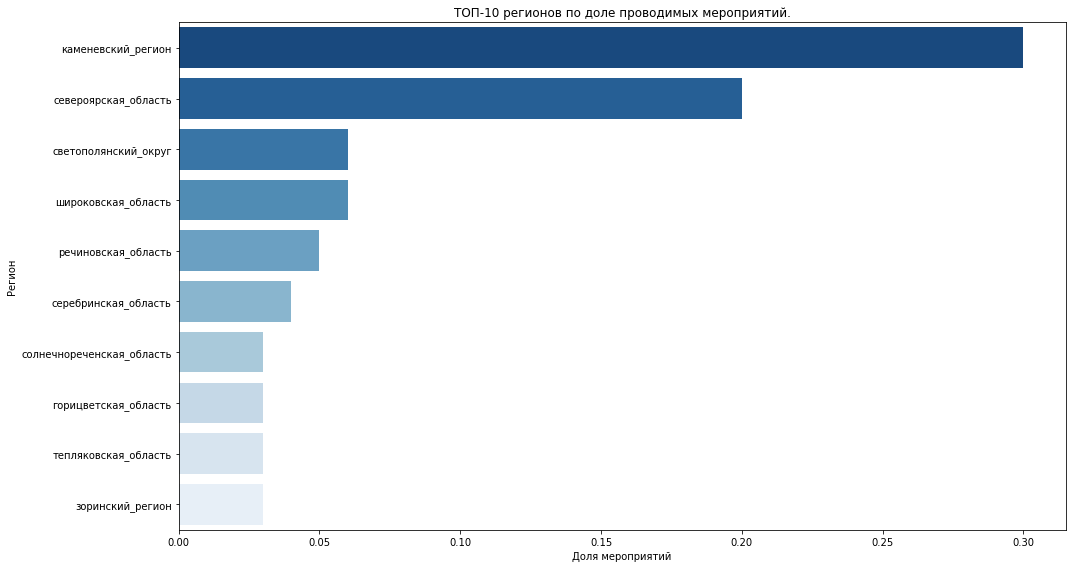

In [115]:
#строим столбчатую диаграмму
plt.figure(figsize=(15,8))
sns.barplot(data=top_10_regions_events, orient='h', y='region_name', x='events_part', palette='Blues_r')
plt.title('ТОП-10 регионов по доле проводимых мероприятий.')
plt.xlabel('Доля мероприятий')
plt.ylabel('Регион')
plt.xticks()
plt.tight_layout()

plt.show() 

Наиболее популярными регионами по доле уникальных мероприятий являются Каменевский регион (3270 мероприятий, что составляет 30% от общего числа), Североярская область (2238 мероприятий, что составляет 20% от общего числа) и Cветополянский округ	 (704 мероприятий, что составляет 6% от общего числа).

Проанализируем общее распределение количества мероприятий.

In [116]:
#выведем основные статистические показатели столбца events_cnt
events_describe=round(regions_df['events_cnt'].describe(), 2)
display(events_describe.reset_index())

,index,events_cnt
0,count,79.00
1,mean,175.76
2,std,450.97
3,min,1.00
4,25%,14.00
5,50%,53.00
6,75%,135.50
7,max,3270.00


Согласно краткому статистическому описанию events_cnt:
* количество регионов составляет 79;
* среднее количество мероприятий, приходящееся на регион составляет 175.76 (то есть 175);
* минимальное количество мероприятий, проводящихся в регионе составило 1 мероприятие;
* максимальное - 3270 мероприятий; 
* наиболее часто встречаются регины, где проводится 53 мероприятия (медиана), что отличается от среднего;
* межквартильный размах равен 135.5-14=121.5;
* стандартное отклонение составляет 450.97.

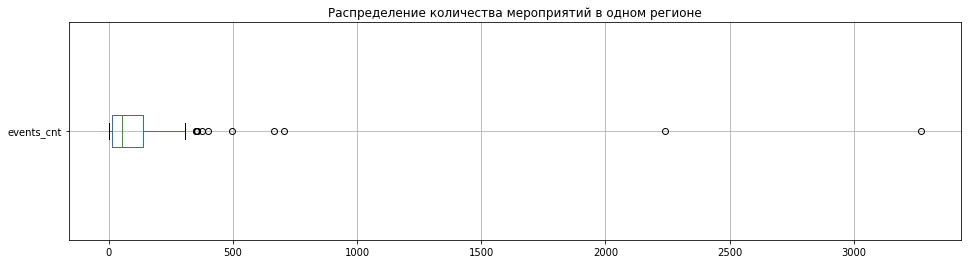

In [117]:
#построим диаграмму размаха
boxplot=regions_df.boxplot(column='events_cnt', vert=False, figsize=(16,4))
boxplot.set_title('Распределение количества мероприятий в одном регионе')
plt.show() 

Распределение асимметричное со скошенностью вправо. Присутствуют выбросы.

---
Выделим топ-10 регионов по количеству заказов.

In [118]:
#выделяем топ-10 по относительному количеству заказов
regions_df=regions_df.sort_values(by='orders_part', ascending=False)
top_10_regions_orders=regions_df.head(10)
display(top_10_regions_orders)

,region_name,events_cnt,orders_cnt,events_part,orders_part
23,каменевский_регион,3270,46576,0.30,0.28
59,североярская_область,2238,20626,0.20,0.12
41,медовская_область,352,12035,0.03,0.07
75,широковская_область,666,8645,0.06,0.05
44,озернинский_край,262,7526,0.02,0.04
40,малиновоярский_округ,136,4412,0.01,0.03
60,серебринская_область,401,4467,0.04,0.03
56,светополянский_округ,704,4752,0.06,0.03
63,солнечноземская_область,356,4193,0.03,0.02
51,речиновская_область,494,3565,0.05,0.02


Визуализируем результат в виде линейчатой диагаммы.

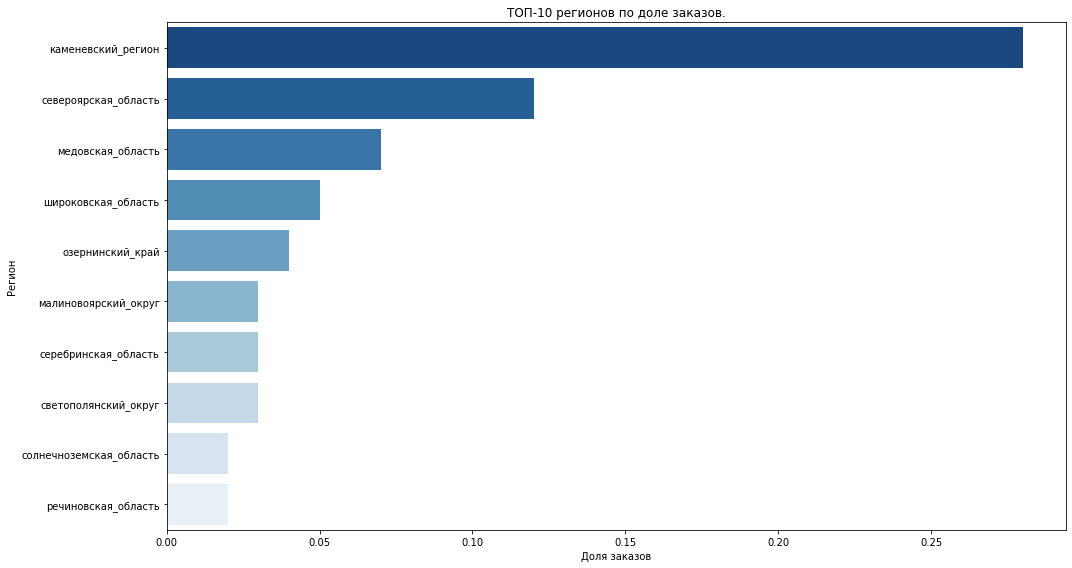

In [119]:
#строим столбчатую диаграмму
plt.figure(figsize=(15,8))
sns.barplot(data=top_10_regions_orders, orient='h', y='region_name', x='orders_part', palette='Blues_r')
plt.title('ТОП-10 регионов по доле заказов.')
plt.xlabel('Доля заказов')
plt.ylabel('Регион')
plt.xticks()
plt.tight_layout()

plt.show() 

Наиболее популярными регионами по доле заказов являются Каменевский регион (46576 заказов, что составляет 28% от общего числа), Североярская область (20626 заказов, что составляет 12% от общего числа) и Медовская область (12035 заказов,что составляет 7% от общего числа). 

Проанализируем общее распределение количества заказов.

In [120]:
#выведем основные статистические показатели столбца orders_cnt
orders_describe=round(regions_df['orders_cnt'].describe(), 2)
display(orders_describe.reset_index())

,index,orders_cnt
0,count,79.00
1,mean,2125.25
2,std,5880.91
3,min,9.00
4,25%,180.00
5,50%,561.00
6,75%,1444.00
7,max,46576.00


Согласно краткому статистическому описанию orders_cnt:
* количество регионов составляет 79;
* среднее количество аказов, приходящееся на регион составляет 2125.25 (то есть 2125);
* минимальное количество заказов, сделанных на территории региона составило 9 заказов;
* максимальное - 46576 заказов; 
* наиболее часто встречаются регины, где был сделан 561 заказ (медиана), что отличается от среднего;
* межквартильный размах равен 1444-180=1264;
* стандартное отклонение составляет 5881.91.

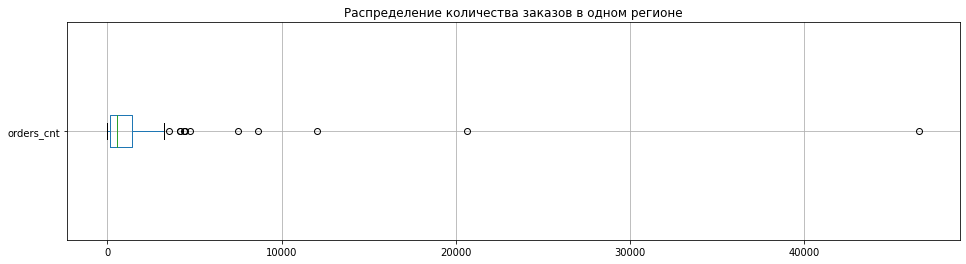

In [121]:
#построим диаграмму размаха
boxplot=regions_df.boxplot(column='orders_cnt', vert=False, figsize=(16,4))
boxplot.set_title('Распределение количества заказов в одном регионе')
plt.show() 

Распределение асимметричное со скошенностью вправо. Присутствуют выбросы.

---
Лидерами среди регионов как по доле мероприятий, так и по доле заказов относительно общего числа являются Каменевский регион и Североярская область.

---
#### 3.3.2 Исследование билетных партнеров
<a class="anchor" id="#332-bullet"></a>

Создадим таблицу для исследований.

In [122]:
#делаем группировку по регионам за осень
service_df=ready_df[ready_df['season']=='осень'].groupby('service_name').agg({'event_name':'nunique',
                                                                              'order_id':'nunique',
                                                                              'revenue_rub': 'sum'}).reset_index()
#для удоства меняем названия колонок
service_df.columns=['service_name', 'events_cnt', 'orders_cnt', 'revenue_sum']

#вычисляем константы для получения значений в долях
total_events=ready_df[ready_df['season']=='осень']['event_name'].nunique()
total_orders=ready_df[ready_df['season']=='осень']['order_id'].nunique()
total_revenue=ready_df[ready_df['season']=='осень']['revenue_rub'].sum()

#создаем столбцы с данными в долях
service_df['events_part']=round(service_df['events_cnt']/total_events, 2)
service_df['orders_part']=round(service_df['orders_cnt']/total_orders, 2)
service_df['revenue_part']=round(service_df['revenue_sum']/total_revenue, 2)

---
Выделим топ-10 сервисов по количеству уникальных мероприятий.

In [123]:
#выделяем топ-10 по относительному количеству мероприятий
service_df=service_df.sort_values(by='events_part', ascending=False)
top_10_service_events=service_df.head(10)
display(top_10_service_events)

,service_name,events_cnt,orders_cnt,revenue_sum,events_part,orders_part,revenue_part
21,лови_билет!,2841,25709,10381964.60,0.26,0.15,0.13
3,билеты_без_проблем,2166,32028,12172643.42,0.20,0.19,0.15
5,билеты_в_руки,2053,25538,7613839.57,0.19,0.15,0.09
22,лучшие_билеты,1193,12349,1676033.68,0.11,0.07,0.02
25,облачко,1124,15478,10611051.69,0.10,0.09,0.13
30,тебе_билет!,748,3759,2166184.84,0.07,0.02,0.03
24,мой_билет,818,19416,10850676.29,0.07,0.12,0.13
26,прачечная,635,5798,2548310.47,0.06,0.03,0.03
8,весь_в_билетах,503,9416,9351278.66,0.05,0.06,0.11
34,яблоко,453,3473,2763332.31,0.04,0.02,0.03


Визуализируем результат в виде линейчатой диагаммы.

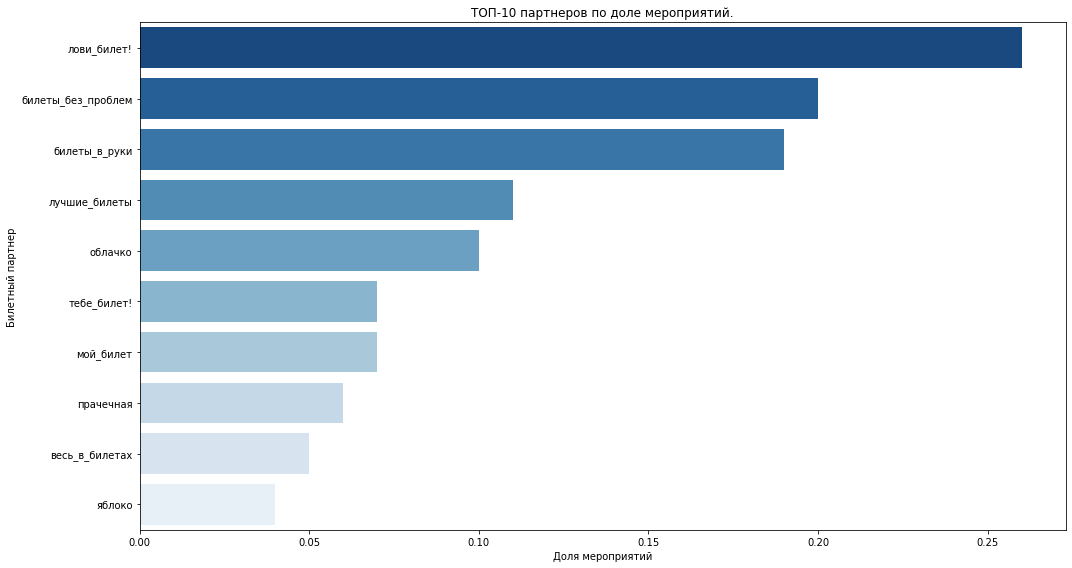

In [124]:
#строим столбчатую диаграмму
plt.figure(figsize=(15,8))
sns.barplot(data=top_10_service_events, orient='h', y='service_name', x='events_part', palette='Blues_r')
plt.title('ТОП-10 партнеров по доле мероприятий.')
plt.xlabel('Доля мероприятий')
plt.ylabel('Билетный партнер')
plt.xticks()
plt.tight_layout()

plt.show() 

Наиболее популярными билетными партнерами по доле уникальных мероприятий являются Лови билет! (2841 мероприятий, что составляет 26% от общего числа), Билеты без проблем (2166 мероприятий, что составляет 20% от общего числа) и Билеты в руки (2053 мероприятий, что составляет 19% от общего числа).

Проанализируем общее распределение количества мероприятий.

In [125]:
#выведем основные статистические показатели столбца events_cnt
describe_events=round(service_df['events_cnt'].describe(), 2)
display(describe_events.reset_index())

,index,events_cnt
0,count,35.00
1,mean,407.51
2,std,690.85
3,min,1.00
4,25%,7.00
5,50%,122.00
6,75%,478.00
7,max,2841.00


Согласно краткому статистическому описанию events_cnt:
* количество билетных партнеров составляет 35;
* среднее количество мероприятий, приходящееся на сервис продажи билетов составляет 407.51 (то есть 407);
* минимальное количество мероприятий, проводящихся на сервис составило 1 мероприятие;
* максимальное - 2841 мероприятий; 
* наиболее часто встречаются сервисы, где продаются билеты на 122 мероприятия (медиана), что отличается от среднего;
* межквартильный размах равен 478-7=471;
* стандартное отклонение составляет 690.85.

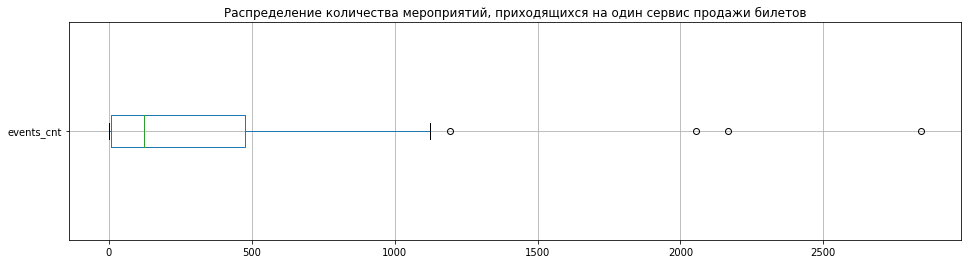

In [126]:
#построим диаграмму размаха
boxplot=service_df.boxplot(column='events_cnt', vert=False, figsize=(16,4))
boxplot.set_title('Распределение количества мероприятий, приходящихся на один сервис продажи билетов')
plt.show() 

Распределение асимметричное со скошенностью вправо. Присутствуют выбросы.

---
Выделим топ-10 сервисов по количеству заказов.

In [127]:
#выделяем топ-10 по относительному количеству заказов
service_df=service_df.sort_values(by='orders_part', ascending=False)
top_10_service_orders=service_df.head(10)
display(top_10_service_orders)

,service_name,events_cnt,orders_cnt,revenue_sum,events_part,orders_part,revenue_part
3,билеты_без_проблем,2166,32028,12172643.42,0.20,0.19,0.15
21,лови_билет!,2841,25709,10381964.60,0.26,0.15,0.13
5,билеты_в_руки,2053,25538,7613839.57,0.19,0.15,0.09
24,мой_билет,818,19416,10850676.29,0.07,0.12,0.13
25,облачко,1124,15478,10611051.69,0.10,0.09,0.13
22,лучшие_билеты,1193,12349,1676033.68,0.11,0.07,0.02
8,весь_в_билетах,503,9416,9351278.66,0.05,0.06,0.11
26,прачечная,635,5798,2548310.47,0.06,0.03,0.03
30,тебе_билет!,748,3759,2166184.84,0.07,0.02,0.03
34,яблоко,453,3473,2763332.31,0.04,0.02,0.03


Визуализируем результат в виде линейчатой диагаммы.

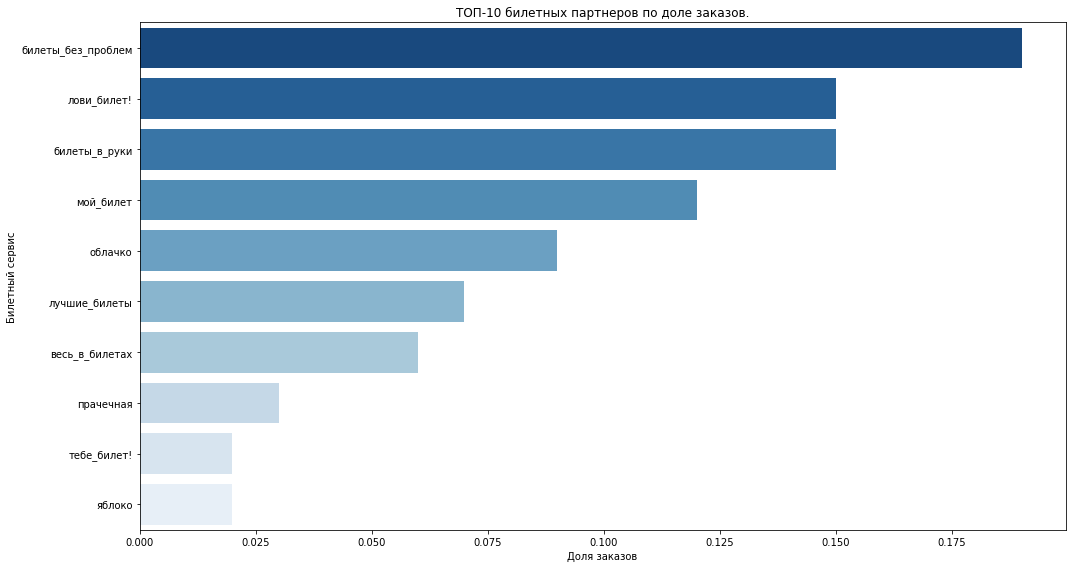

In [128]:
#строим столбчатую диаграмму
plt.figure(figsize=(15,8))
sns.barplot(data=top_10_service_orders, orient='h', y='service_name', x='orders_part', palette='Blues_r')
plt.title('ТОП-10 билетных партнеров по доле заказов.')
plt.xlabel('Доля заказов')
plt.ylabel('Билетный сервис')
plt.xticks()
plt.tight_layout()

plt.show() 

Наиболее популярными билетными партнерами по доле заказов являются Билеты без проблем (32028 заказов, что составляет 19% от общего числа), Лови билет! (25709 заказов, что составляет 15% от общего числа) и Билеты в руки (25538 заказов, что составляет 15% от общего числа).

Проанализируем общее распределение количества заказов.

In [129]:
#выведем основные статистические показатели столбца orders_cnt
describe_orders=round(service_df['orders_cnt'].describe(), 2)
display(describe_orders.reset_index())

,index,orders_cnt
0,count,35.00
1,mean,4797.00
2,std,8531.54
3,min,1.00
4,25%,56.00
5,50%,917.00
6,75%,3616.00
7,max,32028.00


Согласно краткому статистическому описанию orders_cnt:
* количество билетных партнеров составляет 35;
* среднее количество заказов, приходящееся на сервис продажи билетов составляет 4797;
* минимальное количество заказов, проводящихся на сервис составило 1 заказ;
* максимальное - 32028 заказа; 
* наиболее часто встречаются сервисы, где было сделано 917 заказов (медиана), что отличается от среднего;
* межквартильный размах равен 3616-56=3560;
* стандартное отклонение составляет 8531.54.

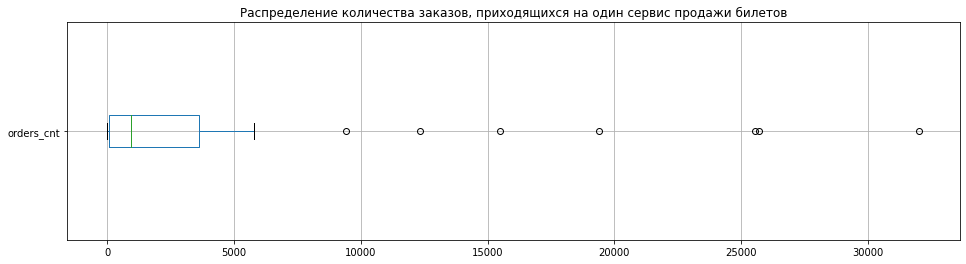

In [130]:
#построим диаграмму размаха
boxplot=service_df.boxplot(column='orders_cnt', vert=False, figsize=(16,4))
boxplot.set_title('Распределение количества заказов, приходящихся на один сервис продажи билетов')
plt.show() 

Распределение асимметричное со скошенностью вправо. Присутствуют выбросы.

---
Выделим топ-10 сервисов по сумме выручки.

In [131]:
#выделяем топ-10 по относительной общей выручке
service_df=service_df.sort_values(by='revenue_part', ascending=False)
top_10_service_revenue=service_df.head(10)
display(top_10_service_revenue)

,service_name,events_cnt,orders_cnt,revenue_sum,events_part,orders_part,revenue_part
3,билеты_без_проблем,2166,32028,12172643.42,0.20,0.19,0.15
24,мой_билет,818,19416,10850676.29,0.07,0.12,0.13
25,облачко,1124,15478,10611051.69,0.10,0.09,0.13
21,лови_билет!,2841,25709,10381964.60,0.26,0.15,0.13
8,весь_в_билетах,503,9416,9351278.66,0.05,0.06,0.11
5,билеты_в_руки,2053,25538,7613839.57,0.19,0.15,0.09
19,край_билетов,181,2997,3018372.54,0.02,0.02,0.04
26,прачечная,635,5798,2548310.47,0.06,0.03,0.03
30,тебе_билет!,748,3759,2166184.84,0.07,0.02,0.03
34,яблоко,453,3473,2763332.31,0.04,0.02,0.03


Визуализируем результат в виде линейчатой диагаммы.

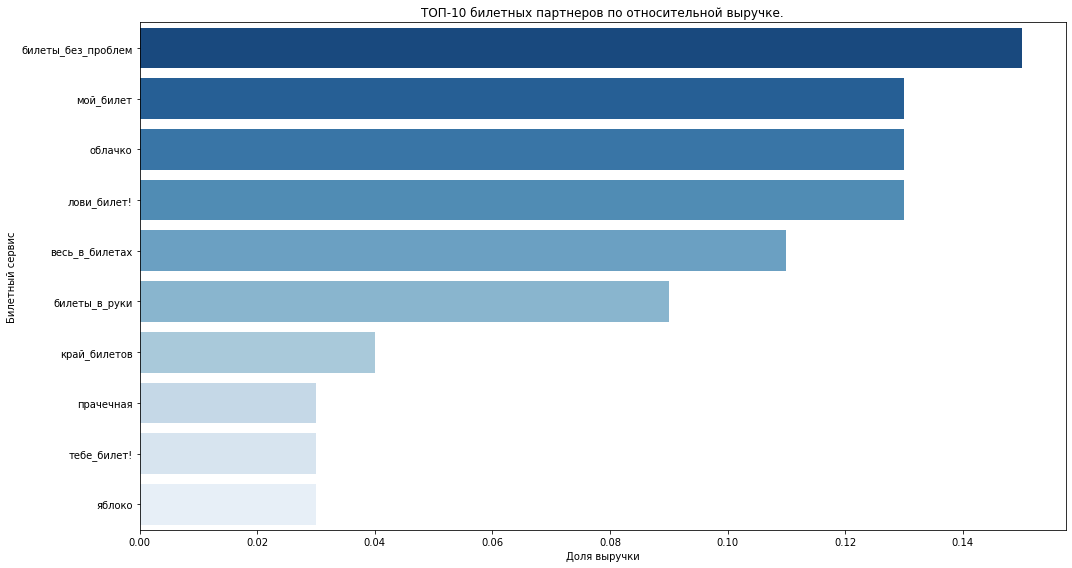

In [132]:
#строим столбчатую диаграмму
plt.figure(figsize=(15,8))
sns.barplot(data=top_10_service_revenue, orient='h', y='service_name', x='revenue_part', palette='Blues_r')
plt.title('ТОП-10 билетных партнеров по относительной выручке.')
plt.xlabel('Доля выручки')
plt.ylabel('Билетный сервис')
plt.xticks()
plt.tight_layout()

plt.show() 

Наиболее популярными билетными партнерами по доле выручки являются Билеты без проблем (12172643.42₽, что составляет 15% от общей суммы), Мой билет (10850676.29₽, что составляет 13% от общей суммы), Облачко(10611051.69₽, что составляет 13% от общей суммы) и Лови билет! (10381964.60₽, что составляет 13% от общей суммы).

Проанализируем общее распределение общей выручки.

In [133]:
#выведем основные статистические показатели столбца revenue_sum
revenue_describe=round(service_df['revenue_sum'].describe(), 2)
display(revenue_describe.reset_index())

,index,revenue_sum
0,count,35.00
1,mean,2339773.89
2,std,3754266.48
3,min,30.01
4,25%,26840.04
5,50%,606630.12
6,75%,2357247.66
7,max,12172643.42


Согласно краткому статистическому описанию revenue_sum:
* количество билетных партнеров составляет 35;
* средняя выручка с сервиса продажи билетов составляет 2339773.89₽;
* минимальная выручка, приходящаяся на сервис составила 30.01₽;
* максимальная - 12173776.67₽; 
* наиболее часто встречаются сервисы, для которых характерна выручка в размере 606630.12₽ (медиана), что отличается от среднего;
* межквартильный размах равен 2357247.66-26840.04=2330407.62;
* стандартное отклонение составляет 3754266.48.

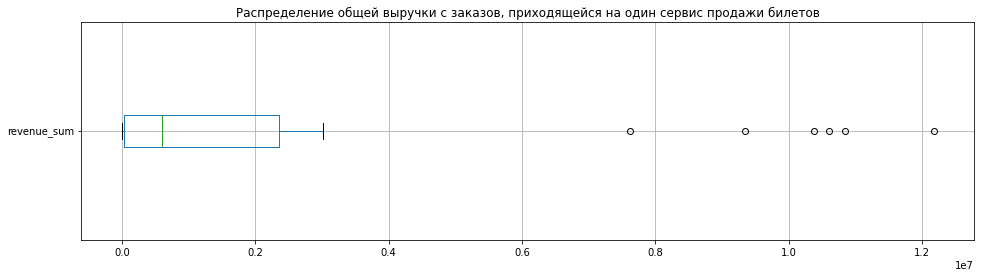

In [134]:
#построим диаграмму размаха
boxplot=service_df.boxplot(column='revenue_sum', vert=False, figsize=(16,4))
boxplot.set_title('Распределение общей выручки с заказов, приходящейся на один сервис продажи билетов')
plt.show() 

Распределение асимметричное со скошенностью вправо. Присутствуют выбросы.

---
Лидерами среди билетных партнеров как по доле мероприятий, так и по доле заказов и относительной общей выручке являются сервисы Билеты без проблем и Лови билет!.

---

## 4. Статистический анализ данных
<a class="anchor" id="#4-bullet"></a>

Проверим две гипотезы относительно активности пользователей мобильных и стационарных устройств, которые предполагают большую активность пользователей мобильных устройств:
* Гипотеза 1: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
* Гипотеза 2:Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

---
### 4.1 Проверка первой гипотезы
<a class="anchor" id="#41-bullet"></a>

- Нулевая гипотеза H₀:  Среднее количество заказов на одного пользователя для мобильного приложения и для стационарных устройств не различается.

- Альтернативная гипотеза H₁: Среднее количество заказов на одного пользователя мобильного приложения выше, чем среднее количество заказов на одного пользователя стационарных устройств, и это различие статистически значимо.

Так как нам надо сравнить среднее количество заказов на одного пользователя для двух выборок, относящихся к разным платформам, вероятно нам следует воспользоваться двухвыборочным t-тестом для проверки гипотезы. Данные должны быть независимы, распределения выборок стремиться к нормальному, а дисперсии должны быть равны.

---
Проверим пересечение пользователей.

In [135]:
#для удобства выделим датафрейм с данными за осень
autumn_ready_df=ready_df[ready_df['season']=='осень']

In [136]:
#сделаем фильтрацию по количеству платформ, к которым относится id пользователя
cnt=len(autumn_ready_df.groupby('user_id').agg({'device_type_canonical':'nunique'}).query('device_type_canonical > 1'))

print(f'Количество пользователей, попавших в две группы, равно {cnt}.')

Количество пользователей, попавших в две группы, равно 3235.


Удалим пользователей, находящихся в двух группах сразу.

In [141]:
#отфильтруем пользователей, участвующих в двух группах
dubls_cnt=autumn_ready_df.groupby('user_id').agg({'device_type_canonical':'nunique'}).query('device_type_canonical > 1')

#создаем копию датафрейма и удаляем строки с данными пользователей, участвующих в нескольких руппах
final_autumn_ready_df=autumn_ready_df.copy()
final_autumn_ready_df=final_autumn_ready_df[~final_autumn_ready_df['user_id'].isin(dubls_cnt.index)]

---
Проверим распределение пользователей.
* Проверим количество пользователей, использующих мобильную и ПК версию.
* Посмотрим, насколько различаются размеры групп.
* Визуализируем процентную разницу в количестве пользователей в группах.

In [142]:
#делаем группировку по типу устройства и узнаем количество уникальных пользователей для каждого
group_cnt=final_autumn_ready_df.groupby('device_type_canonical')['user_id'].agg('nunique')

display(group_cnt.reset_index())

,device_type_canonical,user_id
0,desktop,1627
1,mobile,10875


In [143]:
#рассчитываем процентную разницу в количестве пользователей в группах
difference=round((group_cnt[1]-group_cnt[0])/group_cnt[1]*100, 2)

print(f'Процентная разница в количестве пользоваталей в группах пользователей,, использующих мобильную и ПК версию, составила {difference} %')

Процентная разница в количестве пользоваталей в группах пользователей,, использующих мобильную и ПК версию, составила 85.04 %


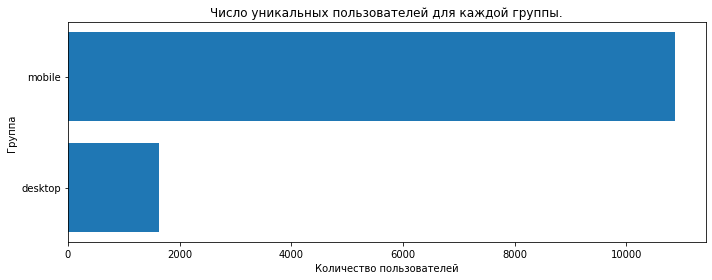

In [144]:
#построим столбчатую диаграмму
plt.figure(figsize=(10,4))
plt.barh(group_cnt.index, group_cnt.values)
plt.title('Число уникальных пользователей для каждой группы.')
plt.ylabel('Группа')
plt.xlabel('Количество пользователей')
plt.tight_layout()

plt.show() 

Количество пользователей сервиса Яндекс Афиша, предпочитающих для заказа билетов мобильное приложение, более чем в 2 раза (85.04%) превышает количество пользователей, делающих заказы с помощью стационарных устройств.

Так как критерий Стьюдента позволяет оценивать различия выборок на основании их средних значений, такая разница в распределении пользователей в группах допускается.

---
Проверим дисперсии.

In [145]:
#вычислим количество заказов для каждого уникального пользователя, относящегося к группе
order_cnt_by_user=final_autumn_ready_df.groupby(['device_type_canonical', 'user_id'])['order_id'].nunique()
order_cnt_by_user=order_cnt_by_user.reset_index()
display(order_cnt_by_user)

,device_type_canonical,user_id,order_id
0,desktop,0040e12d70fae81,1
1,desktop,006d1660d830822,7
2,desktop,00bdfa36a6e542b,1
3,desktop,00cb8c1ef996876,2
4,desktop,00e62ce48c12cb4,2
...,...,...,...
12497,mobile,ffe364dd8211157,3
12498,mobile,ffe73c50cbd71fc,2
12499,mobile,ffed3ff067d4f12,3
12500,mobile,fff13b79bd47d7c,3


In [146]:
#проверим дисперсии в выборках по типам устройств
dispersion=round(order_cnt_by_user.groupby('device_type_canonical')['order_id'].var(), 2)
display(dispersion.reset_index())

,device_type_canonical,order_id
0,desktop,9.31
1,mobile,17.22


In [147]:
#проверим стандартное отклонение
std=round(order_cnt_by_user.groupby('device_type_canonical')['order_id'].std(), 2)
display(std.reset_index())

,device_type_canonical,order_id
0,desktop,3.05
1,mobile,4.15


Дисперсии и значения стандартного отклонения отличаются, для группы, использующей мобильную версию сервиса значения выше, следовательно нет возможности использовать тест Стьюдента. При неравенстве дисперсий используется модификация t-теста - тест Уэлча.

---
Проведем статичтический тест.

In [148]:
#загружаем библиотеки, необходимые для проведения статистического теста
from scipy import stats as st

In [149]:
group_1=order_cnt_by_user[order_cnt_by_user['device_type_canonical']=='desktop']['order_id']
group_2=order_cnt_by_user[order_cnt_by_user['device_type_canonical']=='mobile']['order_id']

alpha=0.05

results=st.ttest_ind(
        group_2,
        group_1,
        equal_var=False,
        alternative='greater'
)

print('p-value =', results.pvalue)

if results.pvalue > alpha:
    print('Статистически значимых различий нет.')
else:
    print('Среднее количество заказов для пользователей в выборках статистически различается.')

p-value = 1.6138950218844191e-25
Среднее количество заказов для пользователей в выборках статистически различается.


В итоге:
* Использовался тест Уэлча со значением alpha=0.05. Тест подходит для двух независимых выборок с неравными дисперсиями. Тест односторонний, что соответствует сформулированным гипотезам Н0 и Н1.
* p-value=1.6138950218844191e-25
* Вывод: среднее количество заказов на каждого пользователя, использующего мобильную версию сервиса Яндекс Афиша, больше, чем для пользователей, предпочитающих ПК версию, и это различие статистически значимо.
* Такой результат может объясняться тем, что мобильная версия более доступна, смартфон в современном мире у всех под рукой, а вот ПК есть не у всех, и к нему может не быть доступа в любое время дня, в отличие от телефона.

---
### 4.1 Проверка второй гипотезы
<a class="anchor" id="#42-bullet"></a>

- Нулевая гипотеза H₀:  Среднее время между заказами пользователей мобильных приложений и стационарных устройств не различается.

- Альтернативная гипотеза H₁: Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств, и это различие статистически значимо.

Снова будем проверять данные на предмет использования двухвыборочного t-теста. Данные должны быть независимы, распределения выборок стремиться к нормальному, а дисперсии должны быть равны. Проверим эти условия.

Так как не у всех пользователей была совершена вторая покупка, снова проанализируем распределения пользователей. Будем рассматривать только тех, для которых столбец days_since_prev заполнен.

In [151]:
#проведем фильтрацию датафрейма, выделив только пользователей, совершивших повторную покупку
days_by_user=final_autumn_ready_df[final_autumn_ready_df['days_since_prev'].notnull()]
display(days_by_user[['order_id', 'user_id', 'device_type_canonical', 'days_since_prev']].head(15))

,order_id,user_id,device_type_canonical,days_since_prev
42,5009432,06c73b84b2405f3,mobile,9.0
43,2790149,087a90accc1e4b0,mobile,75.0
60,3643242,35033a947748839,mobile,10.0
83,5608369,9b7daff217df21f,mobile,40.0
95,459883,c2e3afcac39c500,mobile,7.0
104,5235255,e09c3946bb6aef3,mobile,50.0
105,5235284,e09c3946bb6aef3,mobile,0.0
119,7292370,0005ca5e93f2cf4,mobile,75.0
135,1557446,5281e11bf456280,mobile,3.0
141,3900124,893e15b9a5bd910,mobile,3.0


---
Проверим распределение пользователей.
* Проверим количество пользователей, использующих мобильную и ПК версию.
* Посмотрим, насколько различаются размеры групп.
* Визуализируем процентную разницу в количестве пользователей в группах.

In [152]:
#делаем группировку по типу устройства и узнаем количество уникальных пользователей для каждого
cnt_group=days_by_user.groupby('device_type_canonical')['user_id'].agg('nunique')

display(cnt_group.reset_index())

,device_type_canonical,user_id
0,desktop,903
1,mobile,7029


In [154]:
#рассчитываем процентную разницу в количестве пользователей в группах
difference_per=round((cnt_group[1]-cnt_group[0])/cnt_group[1]*100, 2)

print(f'Процентная разница в количестве пользоваталей в группах пользователей,, использующих мобильную и ПК версию, составила {difference_per} %')

Процентная разница в количестве пользоваталей в группах пользователей,, использующих мобильную и ПК версию, составила 87.15 %


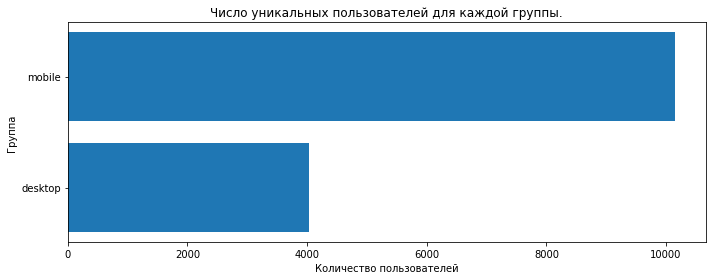

In [106]:
#построим столбчатую диаграмму
plt.figure(figsize=(10,4))
plt.barh(cnt_group.index, cnt_group.values)
plt.title('Число уникальных пользователей для каждой группы.')
plt.ylabel('Группа')
plt.xlabel('Количество пользователей')
plt.tight_layout()

plt.show() 

Разница в распределении пользователей в группах всё еще большая: пользователей, использующих мобильное приложение больше, чем пользователей ПК.

---
Проверим дисперсии.

In [155]:
#проверим дисперсии в выборках по типам устройств
days_dispersion=round(days_by_user.groupby('device_type_canonical')['days_since_prev'].var(), 2)
display(days_dispersion.reset_index())

,device_type_canonical,days_since_prev
0,desktop,1063.13
1,mobile,658.02


In [156]:
#проверим стандартное отклонение
days_std=round(days_by_user.groupby('device_type_canonical')['days_since_prev'].std(), 2)
display(days_std.reset_index())

,device_type_canonical,days_since_prev
0,desktop,32.61
1,mobile,25.65


Для второй гипотезы дисперсии и значения стандартного отклонения тоже отличаются, значит используем тест Уэлча.

---
Проведем статичтический тест.

In [157]:
group_1=days_by_user[days_by_user['device_type_canonical']=='desktop']['days_since_prev']
group_2=days_by_user[days_by_user['device_type_canonical']=='mobile']['days_since_prev']

alpha=0.05

results=st.ttest_ind(
        group_2,
        group_1,
        equal_var=False,
        alternative='greater'
)

print('p-value =', results.pvalue)

if results.pvalue > alpha:
    print('Статистически значимых различий нет.')
else:
    print('Среднее время между заказами для пользователей в выборках статистически различается.')

p-value = 0.9999999981595139
Статистически значимых различий нет.


В итоге:
* Использовался тест Уэлча со значением alpha=0.05. Тест подходит для двух независимых выборок с неравными дисперсиями. Тест односторонний, что соответствует сформулированным гипотезам Н0 и Н1.
* p-value=0.9999999981595139
* Вывод: среднее время между заказами для пользователей, использующих мобильную версию сервиса Яндекс Афиша, стастистически не отличается от среднего времени между заказами для пользователей, предпочитающих ПК версию.

---

## 5. Итоговый вывод
<a class="anchor" id="#5-bullet"></a>

<b>Информация о данных.

- Была проведена загрузка данных и знакомство с ними, выполнен первичный анализ загруженных датафреймов. Было проведено исследование категориальных данных и столбцов с числовыми значениями, на основе которого была выполнена фильтрация.

- Была осуществлена проверка ошибок в данных и их предобработка: данные некоторых столбцов приведены к единому стилю; типы изменены в соответствии с данными, хранящимися в столбцах; пропуски и дубликаты отсутствовали; были созданы новые столбцы, необходимые для дальнейшего анализа.

---
<b>Исследовательский анализ.

Изучение мероприятий:
    
* Наибольшее количество заказов приходится на концерты. Наименее популярными мероприятиями являются ёлки.
* Наибольший относительный рост заказов за осень, по сравнению с летом, отмечается для спортивных мероприятий и ёлок.
* Наибольшая средняя выручка с одного билета приходится на концерты. Меньше всего выручки с одного билета сервис получает от спортивных мероприятий.
* Для большей части типов мероприятий среднее значение выручки с одного билета уменьшилось осенью. Рост показателя наблюдается для выставок и стендапа.

Изучение возрастного рейтинга:
*  Наиболее популярными по количеству заказов являются мероприятия 16+, наименее популяными - мероприятия 18+, что объясняется более узкой аудиторией.
* Наибольший относительный рост заказов за осень, по сравнению с летом, отмечается для мероприятий с рейтингом 0+, наименьший - для мероприятий 18+.
* Изменение средней выручки с одного билета за осень относительно лета для всех рейтингов отрицательное.

Изучение осенней активности пользователей:
* Наблюдается тенденция к росту для количества заказов, количества активных пользователей и числа заказов на одного пользователя.
* Наибольшее количество активных пользователей наблюдается в середине недели, после чего к выходным значение показателя снижается.
* Значение средней стоимости билета изменяется непостоянно. С 20-10 наблюдается уменьшение средней стоимости одного билета.

Изучение регионов и билетных партнеров:
* Лидерами среди регионов как по доле мероприятий, так и по доле заказов относительно общего числа являются Каменевский регион и Североярская область.
* Лидерами среди билетных партнеров как по доле мероприятий, так и по доле заказов и относительной общей выручке являются сервисы Билеты без проблем и Лови билет!.

Результаты проверки гипотез:
<br>Подтверждение нашла только первая гипотеза:
* Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств. Эти различия являются статистически значимыми.
* среднее время между заказами для пользователей, использующих мобильную версию сервиса Яндекс Афиша, стастистически не отличается от среднего времени между заказами для пользователей, предпочитающих ПК версию.

---
<b>Рекомендации.

* Так как осенью наблюдается тенденция к росту для количества заказов, количества активных пользователей и числа заказов на одного пользователя, рекомендуется проводить акции и устанавливать программы лояльности на осенний сезон.
* Для разных категорий сегментов осенью наблюдается рост числа заказов, но выручка с одного билета падает, относительно летнего сезона. Это может быть связано с изменением условий взамодействия с партнерами сервиса. Возможно, следует пересмотреть эти условия.
* Так как наибольшая активность пользователей наблюдается в середине недели, необходимо чаще рекомендовать мероприятия в эти дни недели, а также повышать активность пользователей в выходные.
* Так как по доле мероприятий и по доле заказов лидерами среди регионов являются Каменевский регион и Североярская область, следует увеличить количество акций и программ лояльности для этих регионов.
* Также следует увеличить количество акций при оформлении заказов через наиболее выгодных билетных операторов: Билеты без проблем и Лови билет!.
* Чтобы увеличить количество заказов с ПК следует  улучшить пользовательский опыт: упростить интерфейс и и порядок оплаты.